### Importing Libraries

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder


###
### Data Loading

- Reading Data

In [3]:
# --------  Reading Data -------

tmnst_df = pd.read_csv("tmnst DATA SET.csv")

In [4]:
# ---- Checking some data records ------

tmnst_df.head(5)

,labels,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,F,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,J,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,H,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
tmnst_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74724 entries, 0 to 74723
Columns: 785 entries, labels to 784
dtypes: float64(784), object(1)
memory usage: 447.5+ MB


In [ ]:
tmnst_df[tmnst_df['labels'] == 'D']

,labels,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74582,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74606,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74630,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74633,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


###
### Exploratory Data Analysis

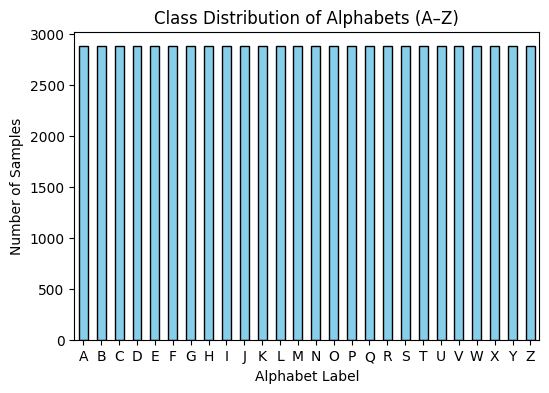

In [ ]:
# Checking the basic Class Distribution

# Count the number of samples per class
class_counts = tmnst_df['labels'].value_counts().sort_index()

# Plotting the distribution
plt.figure(figsize=(6,4))
class_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Class Distribution of Alphabets (A–Z)")
plt.xlabel("Alphabet Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

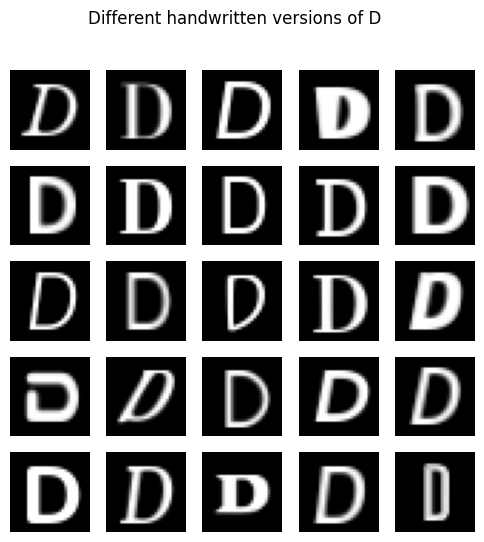

In [ ]:
# Visualizing different versions of D

d_rows = tmnst_df[tmnst_df['labels'] == 'D']

samples = d_rows.sample(25, random_state=42)  # pick 25 D's

fig, axes = plt.subplots(5, 5, figsize=(6,6))
for ax, (_, row) in zip(axes.flatten(), samples.iterrows()):
    image = row.iloc[1:].to_numpy(dtype=float).reshape(28, 28)
    ax.imshow(image, cmap='gray')
    ax.axis('off')
plt.suptitle("Different handwritten versions of D")
plt.show()

In [ ]:
# Identify columns (pixels) with all zeros i.e. no information

zero_cols = tmnst_df.columns[(tmnst_df == 0).all()]

print(f"\nTotal Columns with all zero values : {len(zero_cols)} ")
print("\nColumns with all zero values:\n",list(zero_cols))


Total Columns with all zero values : 95 

Columns with all zero values:
 ['1', '2', '3', '4', '5', '6', '7', '8', '18', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '52', '53', '54', '55', '56', '57', '58', '59', '60', '83', '84', '85', '86', '87', '88', '112', '113', '114', '115', '141', '142', '169', '170', '197', '198', '225', '226', '253', '254', '281', '282', '309', '310', '337', '338', '365', '366', '393', '394', '421', '449', '477', '505', '533', '645', '673', '674', '700', '701', '702', '703', '704', '727', '728', '729', '730', '731', '732', '754', '755', '756', '757', '758', '759', '760', '778', '779', '780', '781', '782', '783', '784']


- Remark : These all zero columns can be dropped from the dataset as this possess no information.

###
### Data Prep

- Dropping the columns with all zero values

In [ ]:
# Loop through each column to check all zero value columns and drop them one by one
cnt = 0
for col in tmnst_df.columns:
    if (tmnst_df[col] == 0).all():
        tmnst_df.drop(columns=col, inplace=True)
        cnt = cnt + 1

print(f"All {cnt} Zero Columns Dropped.")


# Checking the new shape, new column count
print(f"\nNew Column Count is : {tmnst_df.shape[1]}")

All 95 Zero Columns Dropped.

New Column Count is : 690


- Normalising Pixel values in range [0,1] instead of actual [0,255]

In [ ]:
# ------  Normalising Pixel values in range [0,1] instead of actual [0,255] -------------

# Separating Features and Lables
X = tmnst_df.drop(columns=['labels'])         # -- Features
y = tmnst_df['labels']                        # -- Labels

# Normalising the Features in range [0,1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Combining the normalised features with lables in a dataframe
normalized_tmnst_df = pd.DataFrame(X_scaled,
                                 columns=X.columns,
                                 index=X.index)
normalized_tmnst_df['labels'] = y

In [ ]:
normalized_tmnst_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74724 entries, 0 to 74723
Columns: 690 entries, 9 to labels
dtypes: float64(689), object(1)
memory usage: 393.4+ MB


In [ ]:
normalized_tmnst_df.head(6)

,9,10,11,12,13,14,15,16,17,19,...,769,770,771,772,773,774,775,776,777,labels
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,D
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,F
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,J
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,H
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,A
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,G


- Test and Train Data Split

In [ ]:
# ------  Splitting the data as Training and Test in 70/30 Ratio -----

train_df, test_df = train_test_split(
    normalized_tmnst_df,
    test_size=0.3,
    random_state=42,
    stratify=normalized_tmnst_df['labels']
)

In [ ]:
# Checking the shape of the Train and Test DF
print("Training set size:", train_df.shape)
print("Testing set size:", test_df.shape)

Training set size: (52306, 690)
Testing set size: (22418, 690)


###
### PROBLEM 1: Neural Network Classifier

In [ ]:
# Importing libraries for NN
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Input : All the features in the training dataset
X_norm = train_df.drop(columns=['labels']).values            # Features from the Training Set

# Output : all the 26 labels in the training dataset
y_norm = train_df['labels'].values                           # Labels from the Training Set

print(f"X normalised shape : {X_norm.shape}")
print(f"Unique Labels in training dataset : {len(np.unique(y_norm))}\n")

X normalised shape : (52306, 689)
Unique Labels in training dataset : 26



In [ ]:
# Extracting the test features and labels
# =======================================

X_test_norm = test_df.drop(columns=['labels']).values            # Features from the Test Set
y_test_norm = test_df['labels'].values                           # Labels from the Test Set

In [ ]:
# Converting the training data to tensors
X_train_tensor = torch.tensor(X_norm, dtype=torch.float32) # Features

# Encoding the object type labels to numeric values
le = LabelEncoder()
y_encoded = le.fit_transform(y_norm)

y_train_tensor = torch.tensor(y_encoded, dtype=torch.long)  # Labels


# Tensor Dataset and loader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)                    #TensorDataset combines the features and labels in a single dataframe for model training
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)            #DataLoader passes the data in batches, her of size 32 and selects it randomly


# Converting the test data to tensors
# =======================================


# Convert X_test_norm to tensor
X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32)  # Features


# Encode test labels
y_test_encoded = le.fit_transform(y_test_norm)
y_test_encoded = np.asarray(y_test_encoded, dtype=np.int64)

# Convert y test to tensors
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)    # Labels



In [ ]:
# Neural Network Architectures
# =========================

num_features = X_test_tensor.shape[1]
num_classes = 26


class FlexibleNN(nn.Module):                                       # Defining a new class named SingleHiddenNN which inherits all methods from base pytorch class "Module"
    def __init__(self, input_size, hidden_layers, output_size):    # Defines the constructor of the class that accepts input size, hidden layer neurons and output size, Self allows the variables to be attached to class as learnable layers. WIthout it variables will just be local variable
        """
        hidden_layers: list/tuple with sizes of hidden layers
        e.g. [10] for one hidden layer with 10 neurons
             [5,10] for two hidden layers with 5 and 10 neurons
        """
        super(FlexibleNN, self).__init__()                         # Calling the constructor of parent class Module to initialise all internal structure
        layers = []                                                # This defines an empty list called layers, this will have information on whcih all layers needs to be processed one by one of the NN
        in_features = input_size                                   # This keeps track of the number of input features for the current layer being added to the network, To start with, its all the input features of the dataset we want to work with
        for h in hidden_layers:                                    # We initialise a for loop to traverse through each of the hidden layer
            layers.append(nn.Linear(in_features, h))               # Here, we apply a Linear Tranformation on the input features (matrix multiplication of inputs by weights and addition of bias). It takes arguements as input features and output features here is h i.e. the size of the hidden layer and then appends it to the layer of the neural network
            layers.append(nn.ReLU())                               # Here, ReLu adds non-linear ity to the data to allow the model to learn complex patterns. If its >0 it passes the input as output else nothing.
            in_features = h                                        # here, we reassign input features as h i.e. size of hidden layer so that this can become the input list for next layer
        layers.append(nn.Linear(in_features, output_size))         # Once all the hidden layers are traversed, we add the final output lin   ear layer. It takes the updated input feature size i.e. size of the last hidden layer and an output feature which is basically the number of classes we want to work with
        layers.append(nn.Softmax(dim=1))  # Softmax output         # And then we add a softmax activation function to the output layer which basically converts the linea real numners (logits) to probability distribution over the output classes. dim=1 specifies that the softmax is applied along second dimension where batch size is the first dimension. And then added to the layer of the NN
        self.network = nn.Sequential(*layers)                      # Here, we unpack all the defined layers one by one in the sequential order and adds it to nn.Sequential contained which holds the NN defined and the it adds to self.network which basically mean it gets added to the instance of FlexibleNn Class which we are defining

    def forward(self, x):                                          # Here, we are defining a method "forward" for the class. This is where the actual computation happens. Anytime we call an instance of Flexible NN Class, this method is automatically executed, It takes input tensor as arguemnt
        return self.network(x)                                     # It takes input tensor and pass it to self.network and returns the output of the final layer i.e. softmax output activation function as output of forward method


# Training Function
# =========================
def train_model(hidden_layers, epochs=20):                         # Defining a function called train_model that will train the Neural Netrowrk. Arguement hidden_layers will have the number of hidden layers to be created in NN and epochs sets the number of times the NN fully passes through the entire data.
    model = FlexibleNN(num_features, hidden_layers, num_classes)   # Creating an instance of FlexibleNN Class and passing input features, hidden layer and output classes
    criterion = nn.CrossEntropyLoss()                              # Defining the loss function which will be responsible for calculating the loss between predicted output and true output
    optimizer = optim.Adam(model.parameters(), lr=0.0001)          # Defining the optimizer for the training which helps in readjusting the weights of the inputs. it takes model parameters and learning rate as arguement. LR defines the step size to be taken to by optmizer to update weights

    for epoch in range(epochs):                                    # For each epoch defined
        for batch_X, batch_y in train_loader:                      # Another loop inside epoch to fetch a batch of i/p features and a batch of o/p features from trainLoader dataset
            optimizer.zero_grad()                                  # Since gradients in pytorch gets accumulated, this statement clears the gradient or previous batch before calculating the gradient for current batch
            outputs = model(batch_X)                               # batch x is passed to the model for forward pass ad output is stored in output variable
            # CrossEntropyLoss expects raw logits, but here we applied Softmax
            # So instead we compute NLLLoss on log-softmax output
            loss = nn.NLLLoss()(torch.log(outputs), batch_y)       # Calculating the loss here
            loss.backward()                                        # This is nackpropagation, gradient of the loss is calculate wrt model's parameters and these gradient indicate how much each parameter contributed to the loss
            optimizer.step()                                       # This step updates the model's parameters, this is where model learns to adjust its weights to reduce loss
    return model                                                   # returns train model after all epochs are done


# Count Parameters
# =========================
def count_parameters(model):                                       # Defining a function called count_parameters that will count the total number of elements in parameter tensor flow for each parameter that has requires_gras set to true i.e. they are adjusted by optimiser during training
    total = sum(p.numel() for p in model.parameters())             # Total Parameters available in the network
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)  # Only trainable parameter available in the network i.e. whose weights are adjusted by the optimiser
    return total, trainable                                        # returning both count


# Evaluate Accuracy
# =========================
def evaluate(model, features, labels):                             # Defining a function called evaluate to evaluate the accuracy of the model with arguements trained model, features to be tested and results to be tested
    model.eval()                                                   # this part puts the model in evaluation mode. Putting it in evaluation model ensures that model behave correctly to make predictions as model may drop out random parts of NN when in learning mode
    with torch.no_grad():                                          # this step asks the computer to stop keeping track of gradient calculations which are needed for keaning but not actually required for accuracy check. It speeds up the calculation by freeing some nmemory
        outputs = model(features)                                  # Here, we pass the test data/ test features to the trained model and stores the predictions i.e. probabilities in a variable called output
        preds = outputs.argmax(dim=1)                              # It predicts the category/class with highest probability and store it in preds variable
        acc = (preds == labels).float().mean().item()              # Here we calculate the accuracy ans store it in acc, it takes the average of the correct guesses
    return acc                                                     # returns the accurach calculated


# Architectures to Test
# =========================
one_hidden = [[5], [10], [20], [25]]                               # This is the One Hiddle layer architechture we want to test with 5, 10. 20 amd 25 neurons
two_hidden = [[5,5], [5,10], [10,5], [10,10]]                      # This is the Two Hiddle layer architechture we want to test with 5 neurons in first layer and 5 and 10 in second layer, 10 neurons in first layer and 5 and 10 in second layer

architectures = one_hidden + two_hidden                            # Combining all the architechtures to be tetsted


In [ ]:
# Train all models

models = {}                                                        # Creating an empty variable models to save the returned models
for arch in architectures:                                         # Creating a loop for each architechture to be traversed
    print(f"Training architecture {arch}...")                      # Printing the commencement of Training message for each architecture one by one
    models[tuple(arch)] = train_model(arch)                        # returning the trained model and saving it in models variable

print("✅ Training finished for all architectures!")               # Once the training is completed for all architechtures, printing the completion message

Training architecture [5]...
Training architecture [10]...
Training architecture [20]...
Training architecture [25]...
Training architecture [5, 5]...
Training architecture [5, 10]...
Training architecture [10, 5]...
Training architecture [10, 10]...
✅ Training finished for all architectures!


In [ ]:
#models.items()

In [ ]:
# Parameter Count and Evaluation for each NN architechture

results = []                                                       # Defining an empty list to store the finsla results for each architechture i.e. arch name, parameter count and accuracy
for arch, model in models.items():                                 # Creating a loop for each architechture to be traversed
    print(f"Counting Parameters for architecture {arch}...")
    total_params, trainable_params = count_parameters(model)       # Counting the number of parameters using the trained model for a given architechture using the function define dbaove

    print(f"Calculating Accuracy for architecture {arch}...")
    acc = evaluate(model, X_test_tensor, y_test_tensor)            # Calculating the accuracy for trained model using the test data
    #train_acc = evaluate(model, X_train_tensor, y_train_tensor)         # Calculating the accuracy for trained model using the train data

    print(f"Getting the name for the architecture {arch}...")
    arch_name = f"{len(arch)}-" + "-".join(map(str, arch))         # Getting the name of the architechture

    print(f"Appending results for architecture {arch}...")
    results.append([arch_name, total_params, acc])  # Appending the results in variable

print("✅ Evaluation finished!")

Counting Parameters for architecture (5,)...
Calculating Accuracy for architecture (5,)...
Getting the name for the architecture (5,)...
Appending results for architecture (5,)...
Counting Parameters for architecture (10,)...
Calculating Accuracy for architecture (10,)...
Getting the name for the architecture (10,)...
Appending results for architecture (10,)...
Counting Parameters for architecture (20,)...
Calculating Accuracy for architecture (20,)...
Getting the name for the architecture (20,)...
Appending results for architecture (20,)...
Counting Parameters for architecture (25,)...
Calculating Accuracy for architecture (25,)...
Getting the name for the architecture (25,)...
Appending results for architecture (25,)...
Counting Parameters for architecture (5, 5)...
Calculating Accuracy for architecture (5, 5)...
Getting the name for the architecture (5, 5)...
Appending results for architecture (5, 5)...
Counting Parameters for architecture (5, 10)...
Calculating Accuracy for archite

In [ ]:
results

[['1-5', 3606, 0.8457935452461243],
 ['1-10', 7186, 0.9259523749351501],
 ['1-20', 14346, 0.9419662952423096],
 ['1-25', 17926, 0.945579469203949],
 ['2-5-5', 3636, 0.8469533324241638],
 ['2-5-10', 3796, 0.8662235736846924],
 ['2-10-5', 7111, 0.8655544519424438],
 ['2-10-10', 7296, 0.9075742959976196]]

In [ ]:
nn_results_df = pd.DataFrame(results, columns=["Architecture", "Total_Parameters", "Accuracy"])
nn_results_df

,Architecture,Total_Parameters,Accuracy
0,1-5,3606,0.845794
1,1-10,7186,0.925952
2,1-20,14346,0.941966
3,1-25,17926,0.945579
4,2-5-5,3636,0.846953
5,2-5-10,3796,0.866224
6,2-10-5,7111,0.865554
7,2-10-10,7296,0.907574


In [ ]:
# Save the results_df to a csv named NN_Results
nn_results_df.to_csv("NN_Results.csv", index=False)

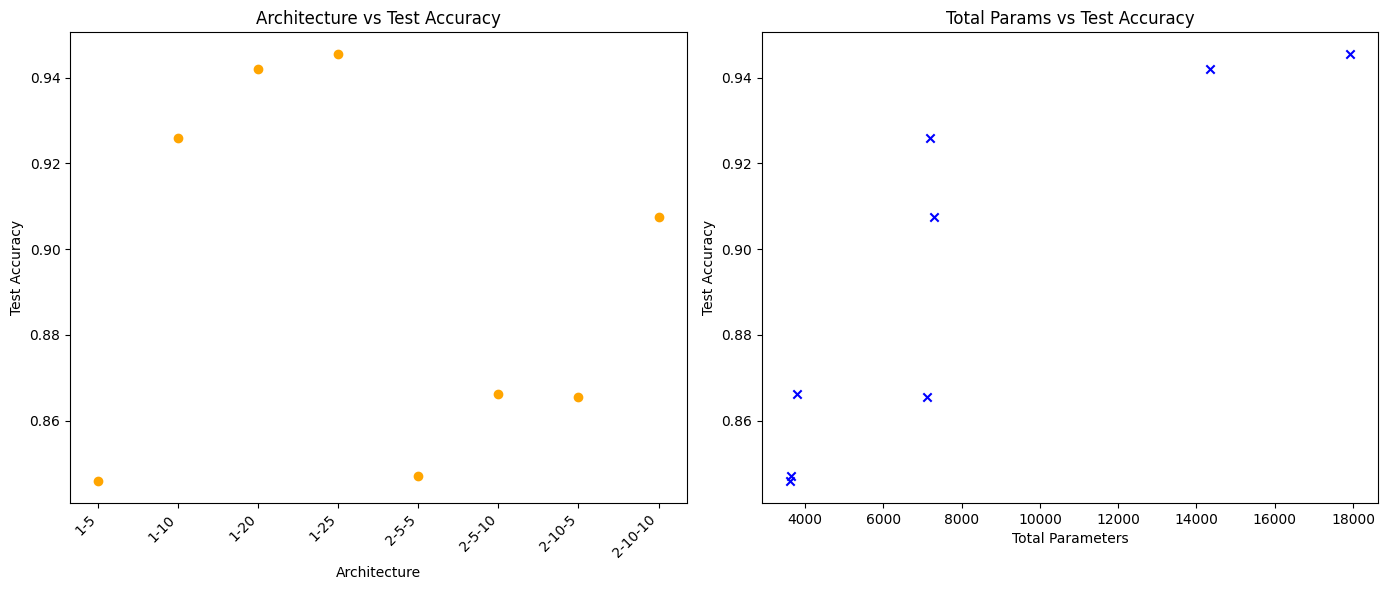

In [ ]:

plt.figure(figsize=(14,6))

# --- Plot 1: Architecture vs Test Accuracy ---
plt.subplot(1, 2, 1)
plt.scatter(nn_results_df["Architecture"], nn_results_df["Accuracy"], color="orange", marker="o")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Architecture")
plt.ylabel("Test Accuracy")
plt.title("Architecture vs Test Accuracy")

# --- Plot 2: Total Parameters vs Test Accuracy ---
plt.subplot(1, 2, 2)
plt.scatter(nn_results_df["Total_Parameters"], nn_results_df["Accuracy"], color="blue", marker="x")
plt.xlabel("Total Parameters")
plt.ylabel("Test Accuracy")
plt.title("Total Params vs Test Accuracy")

plt.tight_layout()
plt.show()

#####
##### **Interpretation** :
- **Total Parameters vs Test Accuracy** :
  - Low performing models:
    -Some models with lowest number of parameters (less than 4K i.e. ~3600 or ~3700) have the lowest accuracy compared to other models i.e. ~84% and ~86%
  - Moderate performing models:
    -Some models with ~7K or ~7100 parameters perform better with much improved accuracy of ~92%
  - High Performing Model:
    -Some models with even higher parameter count ~14K and ~17K has the best accuracy of ~94%.
#####
#####
**Since the difference is not too huge between moderate and high performing models, going with moderate performing model with moderate number of parameters is recommended to achieve an accuracy of ~92%. We should not increase the computational cost by increasing the number of parameters to almost double for a ~2% increase in accuracy unless that ~2% differenceis utmost necessary**
#####
- **Architecture vs Test Accuracy** :
  - Single Hidden Layer:
    - Test Accuracy is maximum for the architecture 1-25 i.e. single hidden layer with 25 neurons i.e. ~95%
    - Accuracy increases significantly as the neurons in hidden layer is increased. Moves upto more than 92% compared to earlier accuracy of less than 85% (with less neurons)
  - Two Hidden Layers
    - Accuracy grows as number of neurons in each layer grows.
    - Highest accuracy achieved is only ~90%

**Overall** :
- Simpler model seems to be working better in this case.
- Decrease in test accuracy with more layers may indicate overfitting but to be sure we will need to check with Training accuracies too.
- If Training Accuracy for 2 layers itself was lesser than single layer then it could be because of other reasons such as less epochs or maybe the data works well with only simpler model and no need to add complexity.

###
### PROBLEM 2 : SVM Classifier

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

def svm_explore(train_data, test_data, c1, c2):                                         # Defining a function svm_explore taking in four arguements i.e. train and test data and two classes that we want to work with
    """

    Various SVM Models to Classification and Prediction Accuracy Comparison

    X for Training Data : X_norm
    y for Training Data : y_norm
    X for Test Data : X_test_norm
    y for Test Data : y_test_norm

    as already created in above steps
    """
    X_train_q2 = X_norm                                                                # Extracting the X and y for Train and Test Data passed. SInce I have already extracted in above part of code, am utilising the same variables
    y_train_q2 = y_norm
    X_test_q2 = X_test_norm
    y_test_q2 = y_test_norm

    # ---  Filter data for only two classes c1 and c2 ---
    # =====================================================
    mask_train_q2 = np.isin(y_train_q2, [c1, c2])                                      # This creates mask_train_q2 of same size as y_train_q2 marking the positions where c1 and c2 exist as TRUE otherwise FALSE
    mask_test_q2 = np.isin(y_test_q2, [c1, c2])                                        # This creates mask_test_q2 of same size as y_test_q2 marking the positions where c1 and c2 exist as TRUE otherwise FALSE

    X_train_q2, y_train_q2 = X_train_q2[mask_train_q2], y_train_q2[mask_train_q2]      # This filters the data from X and y train for positions where masking is True and reassigns to X_train_q2, y_train_q2
    X_test_q2, y_test_q2 = X_test_q2[mask_test_q2], y_test_q2[mask_test_q2]            # This filters the data from X and y test for positions where masking is True and reassigns to X_test_q2, y_test_q2

    # ---- Convert labels to 0/1 for binary SVM ---
    # This part converts the two classes c1 and c2 to binary 0 and 1. Wherever class = c1, result is True and its converted to int 1 and c2 to int 0
    y_train_q2 = (y_train_q2 == c1).astype(int)
    y_test_q2 = (y_test_q2 == c1).astype(int)


    # Defining an empty list results_svm to store model results i.e. model name, support vectors, training accuracy and test accuracy
    results_svm = []

    # --- 1 : Building Linear SVM ---
    # =================================
    for C in range(5, 55, 5):                                                           # This line initiates a for loop for linear SVM with regularization parameter C in range 5 to 5 with an increment of 5
        clf = SVC(kernel="linear", C=C)                                                 # This line initilaises a SVC classifier instance and set the type to Linear SVM with different values of C as the regularised parameter
        clf.fit(X_train_q2, y_train_q2)                                                 # Here, wwe fit the linear SVM classifier to train on training data
        train_acc_q2 = accuracy_score(y_train_q2, clf.predict(X_train_q2))              # Here we calculate the training accuracy with actual and predicted classification
        test_acc_q2 = accuracy_score(y_test_q2, clf.predict(X_test_q2))                 # Here we calculate the testing accuracy with test actual and oredicted classifictaion
        n_support_q2 = clf.n_support_.sum()                                             # This line identifies the number of support vectors i.e. no of data points that lie on the boundary
        results_svm.append([f"Linear/C={C}", n_support_q2, train_acc_q2, test_acc_q2])  # Appending the results for Linear SVM to results_svm variable


    # --- 2 : Building Polynomial SVM ---
    # ====================================
    for d in range(2, 6):                                                               # This defines the loop for Polynomial SVM with various degrees from 2 to 5
        clf = SVC(kernel="poly", degree=d, C=10, coef0=1)                               # defines an instance of nPolynomial SVC with d degrees , c=10 and independent term (constant to be added in case dot product is zero) to 1
        clf.fit(X_train_q2, y_train_q2)                                                 # Polynomial Model Fit
        train_acc_q2 = accuracy_score(y_train_q2, clf.predict(X_train_q2))
        test_acc_q2 = accuracy_score(y_test_q2, clf.predict(X_test_q2))
        n_support_q2 = clf.n_support_.sum()
        results_svm.append([f"Poly/d={d}", n_support_q2, train_acc_q2, test_acc_q2])


    # --- 3 : RBF SVM ---
    # =============================
    for sigma in range(2, 12, 2):
        gamma = 1.0 / (2 * (sigma ** 2))
        clf = SVC(kernel="rbf", gamma=gamma, C=10)                                       # Defining the RBF SVC Model with specified gamma and C=10
        clf.fit(X_train_q2, y_train_q2)
        train_acc_q2 = accuracy_score(y_train_q2, clf.predict(X_train_q2))
        test_acc_q2 = accuracy_score(y_test_q2, clf.predict(X_test_q2))
        n_support_q2 = clf.n_support_.sum()
        results_svm.append([f"RBF/sigma={sigma}", n_support_q2, train_acc_q2, test_acc_q2])


    # --- 4 : Save results to DataFrame ---
    # ========================================
    svm_df = pd.DataFrame(results_svm, columns=["Classifier", "Support Vectors", "Train Acc", "Test Acc"])

    return svm_df


In [ ]:

svm_results_df = svm_explore(train_df, test_df, c1='A', c2='B')

# Save results
svm_results_df.to_csv("svm_results.csv", index=False)

# Display table
print(svm_results_df)


      Classifier  Support Vectors  Train Acc  Test Acc
0     Linear/C=5              139   1.000000  0.988406
1    Linear/C=10              139   1.000000  0.988406
2    Linear/C=15              139   1.000000  0.988406
3    Linear/C=20              139   1.000000  0.988406
4    Linear/C=25              139   1.000000  0.988406
5    Linear/C=30              139   1.000000  0.988406
6    Linear/C=35              139   1.000000  0.988406
7    Linear/C=40              139   1.000000  0.988406
8    Linear/C=45              139   1.000000  0.988406
9    Linear/C=50              139   1.000000  0.988406
10      Poly/d=2              151   1.000000  0.991304
11      Poly/d=3              158   1.000000  0.989565
12      Poly/d=4              157   1.000000  0.989565
13      Poly/d=5              151   1.000000  0.990145
14   RBF/sigma=2             2109   1.000000  0.979710
15   RBF/sigma=4              484   1.000000  0.991304
16   RBF/sigma=6              256   1.000000  0.992464
17   RBF/s

In [ ]:
def plot_svm_results(df):
    # --- Linear ---
    linear_df = df[df["Classifier"].str.contains("Linear")]
    plt.figure(figsize=(6,4))
    plt.plot([int(x.split("=")[1]) for x in linear_df["Classifier"]], linear_df["Train Acc"], label="Train", marker="o")
    plt.plot([int(x.split("=")[1]) for x in linear_df["Classifier"]], linear_df["Test Acc"], label="Test", marker="o")
    plt.xlabel("C")
    plt.ylabel("Accuracy")
    plt.title("Linear SVM")
    plt.legend()
    plt.show()

    # --- Polynomial ---
    poly_df = df[df["Classifier"].str.contains("Poly")]
    plt.figure(figsize=(6,4))
    plt.plot([int(x.split("=")[1]) for x in poly_df["Classifier"]], poly_df["Train Acc"], label="Train", marker="o")
    plt.plot([int(x.split("=")[1]) for x in poly_df["Classifier"]], poly_df["Test Acc"], label="Test", marker="o")
    plt.xlabel("Degree d")
    plt.ylabel("Accuracy")
    plt.title("Polynomial SVM")
    plt.legend()
    plt.show()

    # --- RBF ---
    rbf_df = df[df["Classifier"].str.contains("RBF")]
    plt.figure(figsize=(6,4))
    plt.plot([int(x.split("=")[1]) for x in rbf_df["Classifier"]], rbf_df["Train Acc"], label="Train", marker="o")
    plt.plot([int(x.split("=")[1]) for x in rbf_df["Classifier"]], rbf_df["Test Acc"], label="Test", marker="o")
    plt.xlabel("Sigma")
    plt.ylabel("Accuracy")
    plt.title("RBF SVM")
    plt.legend()
    plt.show()

    # --- Scatter: Support Vectors vs Training Accuracy ---
    plt.figure(figsize=(6,4))
    plt.scatter(df["Support Vectors"], df["Train Acc"], c="orange")
    plt.xlabel("Number of Support Vectors")
    plt.ylabel("Training Accuracy")
    plt.title("Support Vectors vs Training Accuracy")
    plt.show()


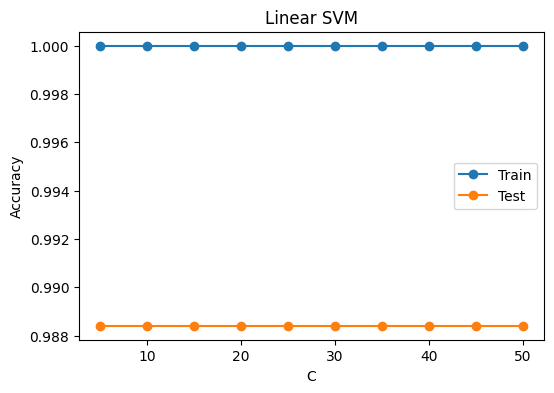

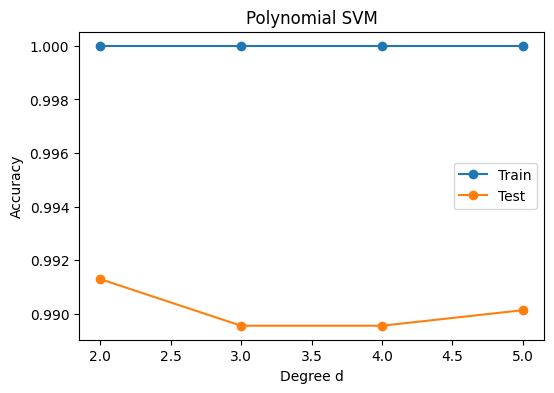

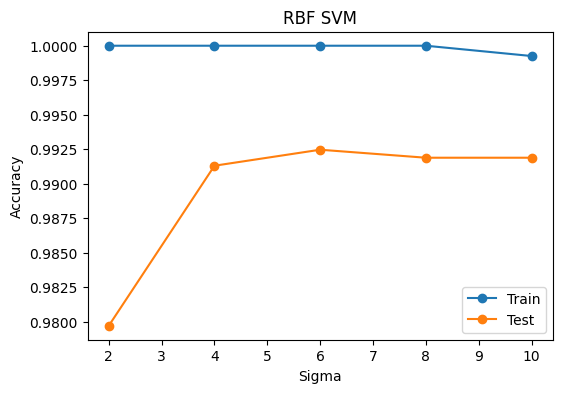

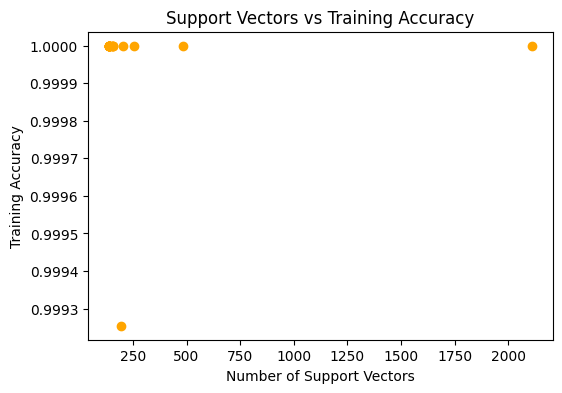

In [ ]:
# For Class A and B
plot_svm_results(svm_results_df)

#####
##### Interpretation for class A and B:
- **Linear SVM : C vs Accuracy (Test and Train) :**
    - Linear SVM for training data gives an accuracy of 100% for class A and B indicating the classes are easily separable in the training data.
    - Accuracy for Training Data is same across all C i.e. regularization parameter has no impact on the class separability. Even with small C, classes are separated nicely with a linear boundary.
    - Test Accuracy is ~98.8% for all values of C. Test Accuracy slightly less than Training Accurach shows minor overfitting but as the difference is very minor, this is not concerning.
    - Overall, Linear SVM Model with varying parameter (C) values separates the class nicely with a wider as well as a narrower margin.
    - The Data is linearly separable. And when the model has found a linear boundary with lower C that separates the data accurately with not much misclassfication to penalise, increasing C has not impacted the number of Support Vectors.
######
- **Polynomial SVM : d vs Accuracy (Test and Train) :**
    - 100% Training Accuracy for all degrees.
    - Varying Test Accuracy with highest accuracy of 99.1% for smallest 'd' and decreasing accuracy as d increases. But the decrease is every minimal. We can say that Test Accuracy is also similar ~99% (~98.9) for all degrees.
    - As we increase the complexity of the model i.e. 'd' the difference between Training and Test Accuracy starts increasing slightly indicating model starts overfitting a little.
    - The data do not need very complex higher degree decision boundary. Its easily separable with just 2 degress as well.
#####
- **RBF SVM : Sigma vs Accuracy (Test and Train) :**
    - At lowest sigma, accuracy is lowest i.e. ~98% compared to other values of sigma. Decision boundary is very wiggly here and may overfit the data.
    - Training and Test Accuracy has highest difference for sigma = 2 (although a small difference) - slight overfitting
    - As sigma increases, decision boundary gets smoother and reaches its max for higher degrees i.e. 6,8 and 10 with an accuracy of ~99%
    - Even though the improvement in accuracy is not too huge for smaller or higher sigma values, a less complex model works very well here as well i.e. with higher sigma of 6 with highest accuracy.
#####
**Overall, the data is easily separable with a linear boundary for classes A and B, a simple, less complex model does the job here.**
**If we are okay with test accuracy of ~98% then we should go with Linear SVM, does the job in the simplest manner, not increasing the complexity of the model, with least number of support vectors.**
**If we dont want to compromise on accuracy and want to have a minimum of 99% accurcay, then we can go with RBF with sigma = 6 but at the cost of increase complexity and highest number of support vectors.**

- **Scatter Plot between Support Vectors and Training Accuracy :**
    - The Training Accuracy is 100% or nearly 100% in all the cases.
    - All the models does a good job in separating these two classes in training data.
    - Some models uses very less support vectors whereas some models have very high number of support vectors.
    - Fewer support vectors provides a very simple clearer boundary.
    - Even when increase the complexity of the model which increases the support vectors, Training accuracy is still the same. We dont need a higher complex model here.

      Classifier  Support Vectors  Train Acc  Test Acc
0     Linear/C=5              119   1.000000  0.987239
1    Linear/C=10              117   1.000000  0.987819
2    Linear/C=15              117   1.000000  0.987819
3    Linear/C=20              117   1.000000  0.987819
4    Linear/C=25              117   1.000000  0.987819
5    Linear/C=30              117   1.000000  0.987819
6    Linear/C=35              117   1.000000  0.987819
7    Linear/C=40              117   1.000000  0.987819
8    Linear/C=45              117   1.000000  0.987819
9    Linear/C=50              117   1.000000  0.987819
10      Poly/d=2              178   0.999751  0.988979
11      Poly/d=3              165   1.000000  0.990719
12      Poly/d=4              154   1.000000  0.990719
13      Poly/d=5              157   1.000000  0.989559
14   RBF/sigma=2             2359   1.000000  0.991299
15   RBF/sigma=4              528   1.000000  0.990719
16   RBF/sigma=6              286   1.000000  0.991299
17   RBF/s

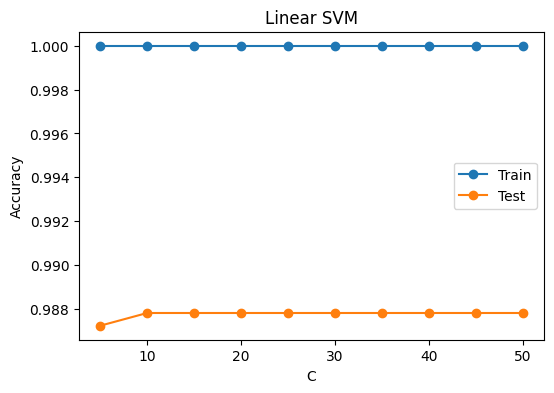

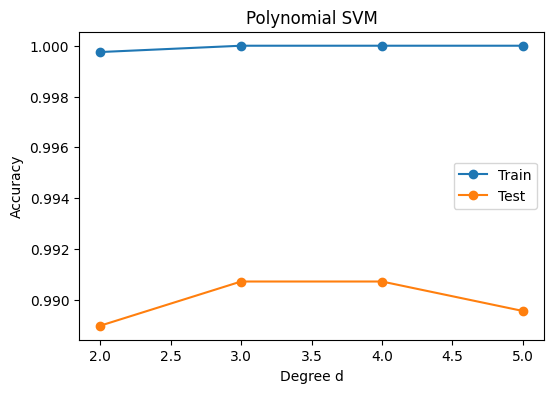

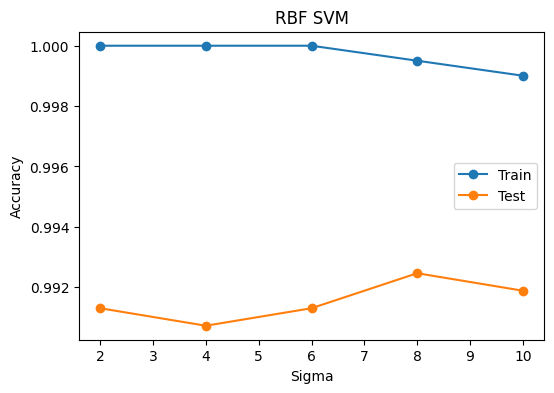

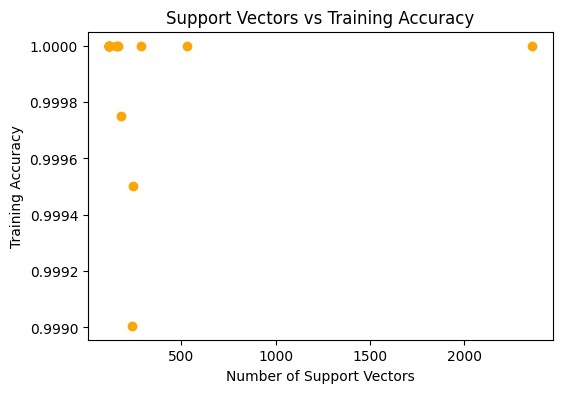

In [ ]:
# For Class D and Q

svm_results_df_D_Q = svm_explore(train_df, test_df, c1='D', c2='Q')

# Save results
svm_results_df_D_Q.to_csv("svm_results_D_Q.csv", index=False)

# Display table
print(svm_results_df_D_Q)

#Plots
plot_svm_results(svm_results_df_D_Q)

#####
##### Interpretation for class D and Q:
- **Linear SVM : C vs Accuracy (Test and Train) :**
    - The Training Accuracy is 100% across all values of regularisation parameter (C)
    - Test Accuracy is highest for C = 10 with ~98.8%
    - Then the accuracy is same for all values of C
#####
- **Polynomial SVM : d vs Accuracy (Test and Train) :**
    - We have the minimum Training and Test Accuracy with smaller degrees. It means we may need to increase the complexity a bit for these two classes for better separability.
    - Test Accuracy is highest for d = 3 and 4
#####
- **RBF SVM : Sigma vs Accuracy (Test and Train) :**
    - Training accuracy is ~100% or very close to ~100% for all values of sigma, model learns the pattern well.
    - Test Accuracy is best at sigma = 8 with lesser number of support vectors compared to sigma 2, 4 and 6.
    - Overall model with moderate complexity works well to separate classes Q and D
#####
- **Scatter Plot between Support Vectors and Training Accuracy :**
    - All the models are able to generalise the training data well with an accuracy of ~99.9% or above.
    - Mostly all models are able to work with support vectors less than 500 with. an exception for SV of ~2K
    - A linear model with C=15, a polynomial model with d=4 and RBF model with Sigma = 8 works well with a Linear SVM having the least number of support vectors.


###
### PROBLEM 3 : Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def random_forrest_explore(train_data, test_data, c1, c2):
    """
    Explore Random Forest performance for given two classes.

    Parameters:
        train_data: tuple (X_train, y_train)
        test_data: tuple (X_test, y_test)
        c1, c2: the two classes to filter data
    """
    X_train_q3 = X_norm                                                                # Extracting the X and y for Train and Test Data passed. SInce I have already extracted in above part of code, am utilising the same variables
    y_train_q3 = y_norm
    X_test_q3 = X_test_norm
    y_test_q3 = y_test_norm

    # ---  Filter data for only two classes c1 and c2 ---
    # =====================================================
    mask_train_q3 = np.isin(y_train_q3, [c1, c2])                                      # This creates mask_train_q3 of same size as y_train_q2 marking the positions where c1 and c2 exist as TRUE otherwise FALSE
    mask_test_q3 = np.isin(y_test_q3, [c1, c2])                                        # This creates mask_test_q3 of same size as y_test_q2 marking the positions where c1 and c2 exist as TRUE otherwise FALSE

    X_train_q3, y_train_q3 = X_train_q3[mask_train_q3], y_train_q3[mask_train_q3]      # This filters the data from X and y train for positions where masking is True and reassigns to X_train_q3, y_train_q3
    X_test_q3, y_test_q3 = X_test_q3[mask_test_q3], y_test_q3[mask_test_q3]            # This filters the data from X and y test for positions where masking is True and reassigns to X_test_q3, y_test_q3

    # ---- Convert labels to 0/1 for binary SVM ---
    # =====================================================
    # This part converts the two classes c1 and c2 to binary 0 and 1. Wherever class = c1, result is True and its converted to int 1 and c2 to int 0
    y_train_q3 = (y_train_q3 == c1).astype(int)
    y_test_q3 = (y_test_q3 == c1).astype(int)


    # --- Random Forest Model Building ---
    # =====================================
    n_trees_list = list(range(5, 105, 5))   # 5 to 100                                 # This creates a variable n_trees_list which keeps a range of values from 5 to 50 with an increment of 5. This will be used for hyperparameter n_estimators which defines the number of trees to be used in the model. More number of trees allows better decision making but increases computation cost.
    depths_list = list(range(3, 11))        # 3 to 10                                  # This creates a variable depths_list which stores values from 3 to 10 with an increment of 1. This variable will be used for hyper parameter max_depth that indicates the depth of individual trees. More depth means better decision making but may lead to overfitting too. Limiting depths mean avoiding overfitting

    # Store Results
    rf_records = []
    #results_train_rf = np.zeros((len(depths_list), len(n_trees_list)))                # Array of size depth * trees for training results
    #results_test_rf = np.zeros((len(depths_list), len(n_trees_list)))                 # Array of size depth * trees for test results


    for i, depth in enumerate(depths_list):                                            # This loop controls the iterations through various depth parameters, we are using index for each depth as well to be able to store row for each index
        for j, n_trees in enumerate(n_trees_list):                                     # This loop controls the iterations through each tree list parameter
            model = RandomForestClassifier(                                            # Defining and creating an instance of Random Forest Model with our parameter list for depth and no. of trees
                n_estimators=n_trees,
                max_depth=depth,
                random_state=42
            )
            model.fit(X_train_q3, y_train_q3)                                          # Fitting the Model on Training Data
            y_pred_train_q3 = model.predict(X_train_q3)                                # Predicting the labels for Training Data
            y_pred_test_q3 = model.predict(X_test_q3)                                  # predicting the labels for Test Data

            train_acc_q3 = accuracy_score(y_train_q3, y_pred_train_q3)                 # Getting Training Accuracy
            test_acc_q3 = accuracy_score(y_test_q3, y_pred_test_q3)                    # Getting Test Accuracy

            # store in arrays
            #results_train_rf[i, j] = train_acc_q3
            #results_test_rf[i, j] = test_acc_q3

            rf_records.append({
                "depth": depth,
                "n_trees": n_trees,
                "train_acc": train_acc_q3,
                "test_acc": test_acc_q3
            })

    # --- Store in DataFrame ---
    # =============================
    rf_results_df = pd.DataFrame(rf_records)



    # ----- Plotting Graphs -----
    # =====================================

    # --- Plot 1: depth vs test and train accuracy (number of lines = number of trees) ---
    plt.figure(figsize=(10, 7))
    for n_trees in n_trees_list:
        subset = rf_results_df[rf_results_df["n_trees"] == n_trees]
        plt.plot(subset["depth"], subset["train_acc"], '--', label=f'Train - Trees={n_trees}')
        plt.plot(subset["depth"], subset["test_acc"], label=f'Test - Trees={n_trees}')
    plt.xlabel("Max Depth")
    plt.ylabel("Accuracy")
    plt.title(f"Effect of Depth (Classes {c1} vs {c2})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='best')
    plt.tight_layout()
    plt.subplots_adjust(top=0.9, bottom=0.1, right=0.8)
    plt.show()

    # --- Plot 2: trees vs test and train accuracy (number of lines = number of depths) ---
    plt.figure(figsize=(10, 7))
    for depth in depths_list:
        subset = rf_results_df[rf_results_df["depth"] == depth]
        plt.plot(subset["n_trees"], subset["train_acc"], '--', label=f'Train - Depth={depth}')
        plt.plot(subset["n_trees"], subset["test_acc"], label=f'Test - Depth={depth}')
    plt.xlabel("Number of Trees")
    plt.ylabel("Accuracy")
    plt.title(f"Effect of Number of Trees (Classes {c1} vs {c2})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='best')
    plt.tight_layout()
    plt.subplots_adjust(top=0.9, bottom=0.1, right=0.8)
    plt.show()





    # ---- Simple conclusion ----
    # =============================
    print("Some pointers for Random Forest Models:")
    print("- Increasing number of trees usually improves stability (reduces variance).")
    print("- Very deep trees (large max_depth) may overfit: high training accuracy, lower test accuracy.")
    print("- Moderate depth with sufficient trees tends to generalize better.")

    return rf_results_df

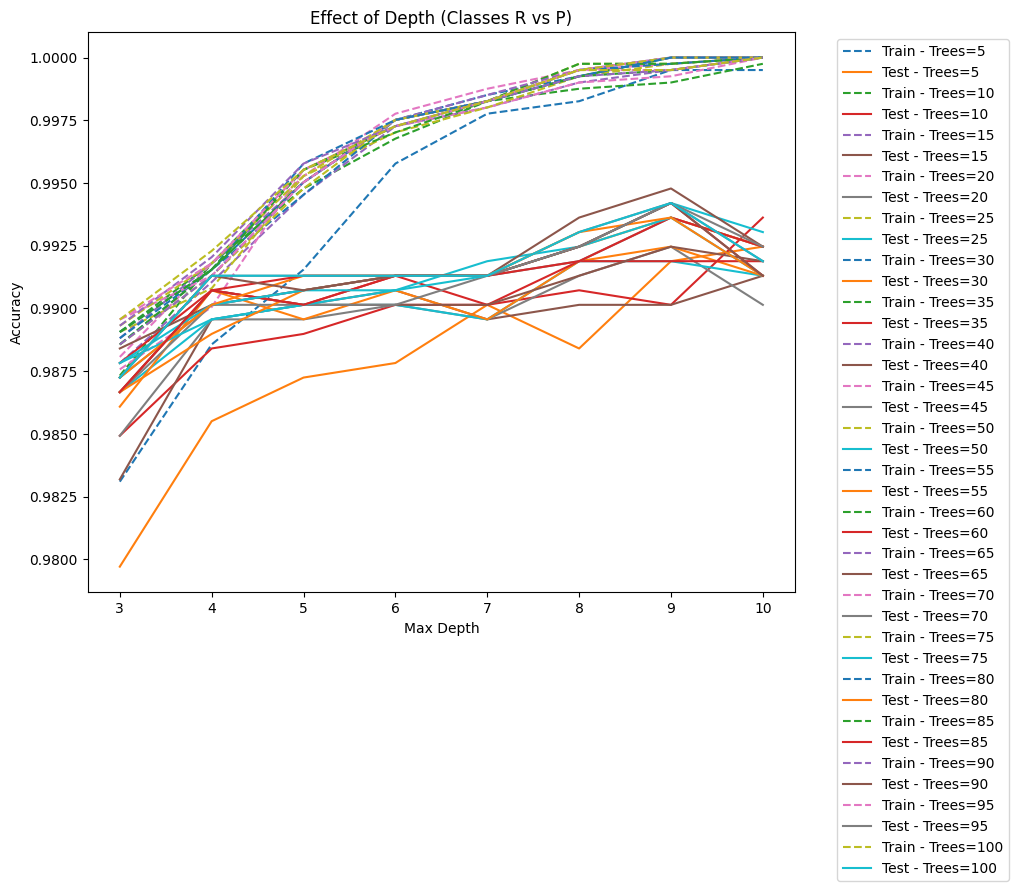

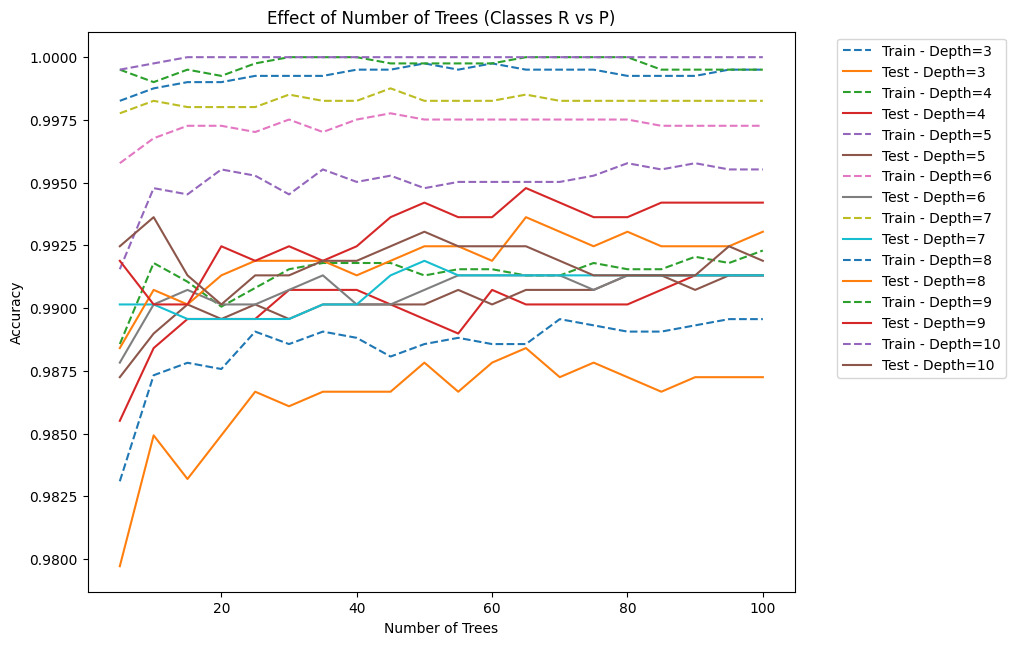

Some pointers for Random Forest Models:
- Increasing number of trees usually improves stability (reduces variance).
- Very deep trees (large max_depth) may overfit: high training accuracy, lower test accuracy.
- Moderate depth with sufficient trees tends to generalize better.


In [ ]:
# Call for two classes, say "R" and "P"
rf_results = random_forrest_explore(train_df, test_df, c1='R', c2='P')

#####
##### **Interpretation** :
- **Depth vs Accuracy:** -- >>
    - At Depth 3, both training and test accuracies are lower compared to deeper trees, with only a small gap between them → model is underfitting but generalizes well.
    - As depth increases from 4 to 7, both training and test accuracies improve significantly. However, training accuracy rises faster, creating a widening gap → slight overfitting appears.
    - Beyond depth 7–8, training accuracy approaches 1.0, while test accuracy plateaus around ~99.2% → adding more depth mainly increases overfitting without boosting test performance.
    - Test accuracy curves are noisier compared to training curves, showing higher variability as depth increases.
    - Overall, shallow trees (3–4) underfit with slightly lower accuracy, while very deep trees (≥8) overfit. The best trade-off is around depth 6–7, which balances high accuracy with limited overfitting.

**Overall Effect of Depth on Accuracy** :
- As depth increases, model improves accuracy but overfitting is more visible.
#####
- **Trees vs Accuracy:** -- >>   
    - General trend:
      - Training accuracy curves are smoother and more accurate.
      - Test accuracy fluctuates more, especially at lower depths.
      - Increasing trees brings stability to the acuracy but it stops increasing much after ~40–50 trees.
    - Depth = 3
      - Lowest accuracy among all depths.
      - Train vs test gap is very small → least overfitting.
      - Around 20+ trees, test accuracy reaches ~98.7–98.8% and stabilizes, but does not improve much with more trees.
    - Depth = 4–6
      - Both training and test accuracy improve compared to depth 3.
      - Test accuracy goes up to ~99.2–99.4%.
      - Overfitting starts to appear — train curves rise higher than test.
      - Test accuracy fluctuates more strongly compared to depth 3.
    - Depth ≥ 7
      - Training accuracy approaches 1.0 (perfect fit).
      - Test accuracy hovers around ~99.5–99.7%, showing diminishing returns.
      - The widening gap between train and test curves highlights stronger overfitting.

In [ ]:
# Printing the Train and Test accuracy output for depth and trees combinations
rf_results

,depth,n_trees,train_acc,test_acc
0,3,5,0.983097,0.979710
1,3,10,0.987323,0.984928
2,3,15,0.987820,0.983188
3,3,20,0.987571,0.984928
4,3,25,0.989063,0.986667
...,...,...,...,...
155,10,80,1.000000,0.991304
156,10,85,1.000000,0.991304
157,10,90,1.000000,0.991304
158,10,95,1.000000,0.992464


In [ ]:
# Save to CSV
rf_results.to_csv('rf_results.csv', index=False)
print(f"Results saved to csv.")

Results saved to csv.


###
### PROBLEM 4 : Pair-wise Classifier

In [31]:
import itertools
from sklearn.model_selection import  cross_val_score
from sklearn.svm import SVC

# ---------------------------------------------------------
# Fisher Score via explicit scatter matrices
# ---------------------------------------------------------
def fisher_lda_feature_ranking(X1, X2, k=30, reg=1e-6, eps=1e-12):
    """
    Compute Fisher scores for two classes using explicit
    between-class and within-class scatter.

    Parameters
    ----------
    X1 : array (n1, d) - samples from class 1  - d-dimesnional array where n1 is the number of sample from class 1
    X2 : array (n2, d) - samples from class 2  - d-dimesnional array where n2 is the number of sample from class 2
    reg : float        - small regularization for numerical stability to provide numerical stability when inversing the SW matrix
    eps : float        - small number to avoid divide-by-zero when normalising the wight vector

    Returns
    -------
    importance : array (d,) - absolute importance per feature
    """

    # --- Means of each class ---
    # -- Here, we intend to calculate the mean of each class X1 and X2 for all the features (axis = 0 inidcates row wise calculation i.e. for each column/feature) --
    # -- Creating a d-dimensional mean vector for each class. Mean for each class is important to identify the Between Class Scatter --
    # =========================
    mu1 = X1.mean(axis=0)                                                            # Mean for each feature for Class X1, mu1 is a vector of length d, where d is the number of dimensions
    mu2 = X2.mean(axis=0)                                                            # Mean for each feature for Class X2, mu2 is also a vector of length d, where d is the number of dimensions.


    # --- Difference of means as column vector ---
    # This will be used in the calculation of between class scatter i.e. SB
    # =================================
    dmu = (mu1 - mu2).reshape(-1, 1)                                                 # dmu is the difference between means of two classes per feature per row (across columns), This is also a d dimensional vector. Reshaping converts to d*1 matrix i.e. d-rows 1-column


    # --- Between-class scatter (SB) ---
    # This matrix quatifies the variance between the means of the two classes.
    # LDA seeks to maximise this variance compared to in class scatter
    # ===================================
    #SB = (mu1 - mu2)(mu1 - mu2)^T
    #print(SB)
    S_B = dmu @ dmu.T                                                                # Calculating between class scatter as dmu * dmu transpose. S_B is a d x d matrix


    # --- Within-class scatter ---
    # Here we calculate the within class scatter i.e. the variance in each class around its mean
    # To calculate this, we first centre the data for each class by subtracting the values from the mean of that class
    # =======================================
    X1c = X1 - mu1                                                                   # Data Centering for class X1
    X2c = X2 - mu2                                                                   # Data Cenering for Class X2
    S_W = X1c.T @ X1c + X2c.T @ X2c                                                  # Calculating within class scatter by summing up the covariance matrices of each class


    # --- Regularize to avoid singular matrix ---
    # Regularisation helps add a small value to the diagonal elements of S_W to add numerical stability to matrix inversion
    # Adding a small constant ensure that S_W does not get converted to Singular Matrix i.e. determinant of zero as this makes impossible to invert SW
    # ==================================================
    S_W_reg = S_W + reg * np.eye(S_W.shape[0])                                       # Gets the d-dimensional identity matrix, adds a regularisation constant to S_W



    # --- Solve generalized eigenvalue problem: SB w = λ SW w ---
    eigvals, eigvecs = np.linalg.eig(np.linalg.inv(S_W_reg) @ S_B)                   # Getting the eigen vectors (directions) and eigen values (magnitude) in transformed space by matrix multiplication between SB and inverse of SW. These eigen vectors are the linear discriminant that helps ientify top k projections for feature extraction


    # --- Sort eigenvalues (descending) ---
    sorted_idx = np.argsort(-eigvals.real)                                           # Here, we sort the eigen values in descending order. By default argsort sorts in acsending, multiplying by -1 the real part of eigen values sorts in decreasing order


    # --- Select top-k ---
    W_top = eigvecs[:, sorted_idx[:k]].real                                          # Creating a projection matrix W_top that has top k real values of eigen vector

    return W_top, sorted_idx[:k]                                                     # returning the top k eigen vectors and indices of top k eigen values



# ---------------------------------------------------------
# Main pairwise classifier loop
# ---------------------------------------------------------
def run_pairwise_svm(X, y, class_labels, C):
    """
    Run pairwise Fisher+SVM for all class pairs.
    X : numpy array of shape (n_samples, n_features)
    y : numpy array of shape (n_samples,)
    class_labels : list of unique class labels
    C : float, regularization parameter for SVM
    """
    results = []
    feature_indices = {}   # store top-30 indices per class pair

    for c1, c2 in itertools.combinations(class_labels, 2):
        # Extract data for the pair
        mask = (y == c1) | (y == c2)
        X_pair, y_pair = X[mask], y[mask]

        # Remove all-zero columns
        nonzero_mask = np.any(X_pair != 0, axis=0)
        X_pair = X_pair[:, nonzero_mask]

        # Get top-30 Fisher projection
        top30_vecs, top30_idx = fisher_lda_feature_ranking(X_pair[y_pair==c1], X_pair[y_pair==c2])

        # Project data
        X_proj = X_pair @ top30_vecs

        # Train SVM with cross-validation
        clf = SVC(kernel="linear", C=C) # Using linear kernel as requested
        acc = cross_val_score(clf, X_proj, y_pair, cv=5).mean()

        # Save results
        results.append((c1, c2, acc))
        feature_indices[(c1, c2)] = top30_idx.tolist()


    return results, feature_indices


In [ ]:
# Getting the training and Test Data (features and labels)
X_train_q4 = X_norm
y_train_q4 = y_norm
X_test_q4 = X_test_norm
y_test_q4 = y_test_norm

# Getting the unique classes we have in test data (validation set)
class_labels = np.unique(y_test_q4)

###
### Executing the Linear SVM with top 30 features for C = 50

Pair (A,B) -> Accuracy: 0.996
Pair (A,B) -> Top-30 Fisher dimensions: [0, 1, 9, 8, 21, 11, 10, 32, 28, 29, 41, 30, 31, 27, 26, 63, 62, 61, 60, 59, 71, 70, 58, 57, 83, 89, 88, 87, 86, 73]
Pair (A,C) -> Accuracy: 0.931
Pair (A,C) -> Top-30 Fisher dimensions: [0, 3, 4, 7, 16, 15, 30, 31, 29, 28, 36, 22, 21, 41, 42, 55, 49, 50, 68, 69, 40, 39, 58, 59, 64, 65, 38, 37, 96, 103]
Pair (A,D) -> Accuracy: 0.999
Pair (A,D) -> Top-30 Fisher dimensions: [0, 3, 4, 7, 8, 17, 18, 23, 22, 35, 36, 39, 28, 29, 49, 48, 46, 47, 69, 70, 52, 53, 65, 66, 82, 19, 20, 37, 38, 100]
Pair (A,E) -> Accuracy: 0.994
Pair (A,E) -> Top-30 Fisher dimensions: [0, 1, 2, 3, 4, 13, 12, 21, 20, 49, 48, 28, 27, 58, 59, 14, 15, 51, 50, 63, 62, 69, 68, 73, 72, 90, 61, 60, 87, 86]
Pair (A,F) -> Accuracy: 0.893
Pair (A,F) -> Top-30 Fisher dimensions: [0, 14, 13, 17, 21, 20, 16, 15, 1, 2, 26, 27, 18, 19, 24, 25, 10, 9, 54, 53, 61, 74, 75, 72, 73, 90, 67, 66, 94, 93]
Pair (A,G) -> Accuracy: 0.998
Pair (A,G) -> Top-30 Fisher dimensi

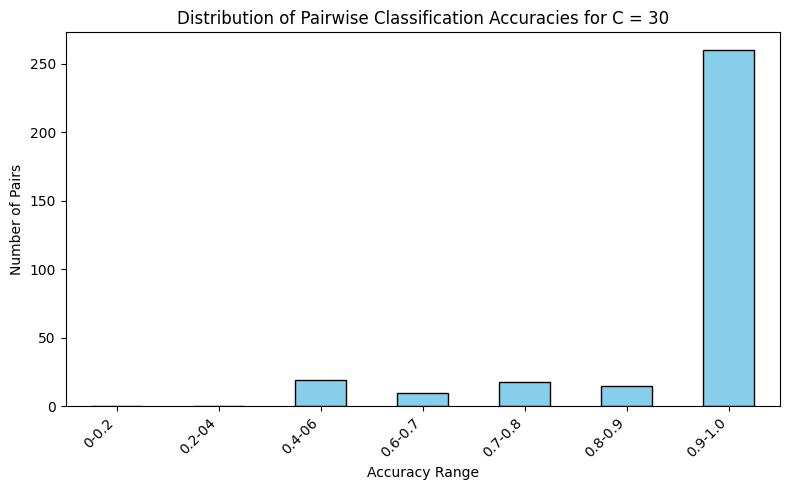

No pairs have the same set of 30 features.
results_pairwise_df for C=50 saved as csv.
feature_indices_pairwise_df for C=50 saved as csv.


In [48]:


# Run pairwise SVM with linear kernel and C=50
results_pairwise_df_C50, feature_indices_pairwise_C50 = run_pairwise_svm(X_test_q4, y_test_q4, class_labels, C=50)


# Print results for accuracy and top 30 features
for c1, c2, acc in results_pairwise_df_C50:
  print(f"Pair ({c1},{c2}) -> Accuracy: {acc:.3f}")
  print(f"Pair ({c1},{c2}) -> Top-30 Fisher dimensions: {feature_indices_pairwise_C50[(c1, c2)]}")


# Converting the results_pairwise accuracy to a dataframe
results_pairwise_df_C50 = pd.DataFrame(results_pairwise_df_C50, columns=["Class 1", "Class 2", "Accuracy"])
results_pairwise_df_C50.head(100)

# Convert the top 30 feature dictionary to a list of lists for DataFrame creation
feature_indices_list_C50 = []
for pair, indices in feature_indices_pairwise_C50.items():
    feature_indices_list_C50.append([pair[0], pair[1], indices])

# Converting to dataframe
feature_indices_pairwise_df_C50 = pd.DataFrame(feature_indices_list_C50, columns=["Class 1", "Class 2", "Top-30 Fisher dimensions"])
feature_indices_pairwise_df_C50.head(5)



# Seeing the distribution of pairs as per varied range of Accuracy bins for C =50
# Define accuracy bins
accuracy_bins = [0.0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0]
accuracy_labels = ['0-0.2','0.2-04','0.4-06', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']

# Categorize accuracies into bins
accuracy_ranges_C50 = pd.cut(results_pairwise_df_C50['Accuracy'], bins=accuracy_bins, labels=accuracy_labels, right=False)

# Get the count of pairs in each range
accuracy_counts_C50 = accuracy_ranges_C50.value_counts().sort_index()

# Print the results
print("Pair count for various accuracy ranges:")
print(accuracy_counts_C50)

# Plot the distribution
plt.figure(figsize=(8, 5))
accuracy_counts_C50.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of Pairwise Classification Accuracies for C = 50")
plt.xlabel("Accuracy Range")
plt.ylabel("Number of Pairs")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Check for whether any class pair has same set of top 30 features
# Create a Series of feature sets as strings for easier comparison
feature_sets_C50 = feature_indices_pairwise_df_C50.iloc[:, 2:].apply(
    lambda row: ','.join(map(str, row.values)), axis=1
)

# Find duplicate feature sets
duplicate_sets_C50 = feature_sets_C50[feature_sets_C50.duplicated(keep=False)]

if not duplicate_sets_C50.empty:
    print("Pairs with duplicate feature sets:")
    # Get the indices of the duplicate sets
    duplicate_indices_C50 = duplicate_sets_C50.index

    # Print the corresponding class pairs and their feature sets
    for idx in duplicate_indices_C50:
        class1 = feature_indices_pairwise_df_C50.loc[idx, 'Class 1']
        class2 = feature_indices_pairwise_df_C50.loc[idx, 'Class 2']
        features = duplicate_sets_C50.loc[idx]
        print(f"  Pair ({class1}, {class2}) has feature set: [{features_C50}]")
else:
    print("No pairs have the same set of 30 features.")



# Save the results_pairwise_df to a csv for C = 50
results_pairwise_df_C50.to_csv("pairwise_results_C50.csv", index=False)
print("results_pairwise_df for C=50 saved as csv.")

# Save the feature_indices_pairwise_df to a csv for C = 50
feature_indices_pairwise_df_C50.to_csv("pairwise_feature_indices_C50.csv", index=False)
print("feature_indices_pairwise_df for C=50 saved as csv.")

###
### Executing the Linear SVM with top 30 features for C = 30

Pair (A,B) -> Accuracy: 0.993
Pair (A,B) -> Top-30 Fisher dimensions: [0, 1, 9, 8, 21, 11, 10, 32, 28, 29, 41, 30, 31, 27, 26, 63, 62, 61, 60, 59, 71, 70, 58, 57, 83, 89, 88, 87, 86, 73]
Pair (A,C) -> Accuracy: 0.682
Pair (A,C) -> Top-30 Fisher dimensions: [0, 3, 4, 7, 16, 15, 30, 31, 29, 28, 36, 22, 21, 41, 42, 55, 49, 50, 68, 69, 40, 39, 58, 59, 64, 65, 38, 37, 96, 103]
Pair (A,D) -> Accuracy: 0.998
Pair (A,D) -> Top-30 Fisher dimensions: [0, 3, 4, 7, 8, 17, 18, 23, 22, 35, 36, 39, 28, 29, 49, 48, 46, 47, 69, 70, 52, 53, 65, 66, 82, 19, 20, 37, 38, 100]
Pair (A,E) -> Accuracy: 0.582
Pair (A,E) -> Top-30 Fisher dimensions: [0, 1, 2, 3, 4, 13, 12, 21, 20, 49, 48, 28, 27, 58, 59, 14, 15, 51, 50, 63, 62, 69, 68, 73, 72, 90, 61, 60, 87, 86]
Pair (A,F) -> Accuracy: 0.747
Pair (A,F) -> Top-30 Fisher dimensions: [0, 14, 13, 17, 21, 20, 16, 15, 1, 2, 26, 27, 18, 19, 24, 25, 10, 9, 54, 53, 61, 74, 75, 72, 73, 90, 67, 66, 94, 93]
Pair (A,G) -> Accuracy: 0.998
Pair (A,G) -> Top-30 Fisher dimensi

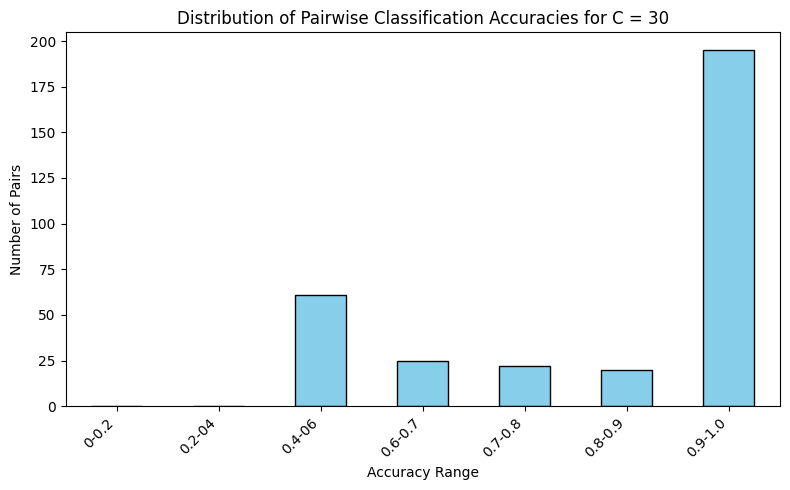

No pairs have the same set of 30 features.
results_pairwise_df for C=30 saved as csv.
feature_indices_pairwise_df for C=30 saved as csv.


In [47]:


# Run pairwise SVM with linear kernel and C=30
results_pairwise_df_C30, feature_indices_pairwise_C30 = run_pairwise_svm(X_test_q4, y_test_q4, class_labels, C=30)


# Print results for accuracy and top 30 features
for c1, c2, acc in results_pairwise_df_C30:
  print(f"Pair ({c1},{c2}) -> Accuracy: {acc:.3f}")
  print(f"Pair ({c1},{c2}) -> Top-30 Fisher dimensions: {feature_indices_pairwise_C30[(c1, c2)]}")


# Converting the results_pairwise accuracy to a dataframe
results_pairwise_df_C30 = pd.DataFrame(results_pairwise_df_C30, columns=["Class 1", "Class 2", "Accuracy"])
results_pairwise_df_C30.head(100)

# Convert the top 30 feature dictionary to a list of lists for DataFrame creation
feature_indices_list_C30 = []
for pair, indices in feature_indices_pairwise_C30.items():
    feature_indices_list_C30.append([pair[0], pair[1], indices])

# Converting to dataframe
feature_indices_pairwise_df_C30 = pd.DataFrame(feature_indices_list_C30, columns=["Class 1", "Class 2", "Top-30 Fisher dimensions"])
feature_indices_pairwise_df_C30.head(5)



# Seeing the distribution of pairs as per varied range of Accuracy bins for C =30
# Define accuracy bins
accuracy_bins = [0.0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0]
accuracy_labels = ['0-0.2','0.2-04','0.4-06', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']

# Categorize accuracies into bins
accuracy_ranges_C30 = pd.cut(results_pairwise_df_C30['Accuracy'], bins=accuracy_bins, labels=accuracy_labels, right=False)

# Get the count of pairs in each range
accuracy_counts_C30 = accuracy_ranges_C30.value_counts().sort_index()

# Print the results
print("Pair count for various accuracy ranges:")
print(accuracy_counts_C30)

# Plot the distribution
plt.figure(figsize=(8, 5))
accuracy_counts_C30.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of Pairwise Classification Accuracies for C = 30")
plt.xlabel("Accuracy Range")
plt.ylabel("Number of Pairs")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Check for whether any class pair has same set of top 30 features
# Create a Series of feature sets as strings for easier comparison
feature_sets_C30 = feature_indices_pairwise_df_C30.iloc[:, 2:].apply(
    lambda row: ','.join(map(str, row.values)), axis=1
)

# Find duplicate feature sets
duplicate_sets_C30 = feature_sets_C30[feature_sets_C30.duplicated(keep=False)]

if not duplicate_sets_C30.empty:
    print("Pairs with duplicate feature sets:")
    # Get the indices of the duplicate sets
    duplicate_indices_C30 = duplicate_sets_C30.index

    # Print the corresponding class pairs and their feature sets
    for idx in duplicate_indices_C30:
        class1 = feature_indices_pairwise_df_C30.loc[idx, 'Class 1']
        class2 = feature_indices_pairwise_df_C30.loc[idx, 'Class 2']
        features = duplicate_sets_C30.loc[idx]
        print(f"  Pair ({class1}, {class2}) has feature set: [{features_C30}]")
else:
    print("No pairs have the same set of 30 features.")



# Save the results_pairwise_df to a csv for C = 30
results_pairwise_df_C30.to_csv("pairwise_results_C30.csv", index=False)
print("results_pairwise_df for C=30 saved as csv.")

# Save the feature_indices_pairwise_df to a csv for C = 30
feature_indices_pairwise_df_C30.to_csv("pairwise_feature_indices_C30.csv", index=False)
print("feature_indices_pairwise_df for C=30 saved as csv.")

###
### **Executing the Linear SVM with top 30 features for C = 20**

In [24]:


# Run pairwise SVM with linear kernel and C=20
results_pairwise_df, feature_indices_pairwise = run_pairwise_svm(X_test_q4, y_test_q4, class_labels, C=20)


# Print results for accuracy and top 30 features
for c1, c2, acc in results_pairwise_df:
  print(f"Pair ({c1},{c2}) -> Accuracy: {acc:.3f}")
  print(f"Pair ({c1},{c2}) -> Top-30 Fisher dimensions: {feature_indices_pairwise[(c1, c2)]}")

Pair (A,B) -> Accuracy: 0.614
Pair (A,B) -> Top-30 Fisher dimensions: [0, 1, 9, 8, 21, 11, 10, 32, 28, 29, 41, 30, 31, 27, 26, 63, 62, 61, 60, 59, 71, 70, 58, 57, 83, 89, 88, 87, 86, 73]
Pair (A,C) -> Accuracy: 0.496
Pair (A,C) -> Top-30 Fisher dimensions: [0, 3, 4, 7, 16, 15, 30, 31, 29, 28, 36, 22, 21, 41, 42, 55, 49, 50, 68, 69, 40, 39, 58, 59, 64, 65, 38, 37, 96, 103]
Pair (A,D) -> Accuracy: 0.997
Pair (A,D) -> Top-30 Fisher dimensions: [0, 3, 4, 7, 8, 17, 18, 23, 22, 35, 36, 39, 28, 29, 49, 48, 46, 47, 69, 70, 52, 53, 65, 66, 82, 19, 20, 37, 38, 100]
Pair (A,E) -> Accuracy: 0.497
Pair (A,E) -> Top-30 Fisher dimensions: [0, 1, 2, 3, 4, 13, 12, 21, 20, 49, 48, 28, 27, 58, 59, 14, 15, 51, 50, 63, 62, 69, 68, 73, 72, 90, 61, 60, 87, 86]
Pair (A,F) -> Accuracy: 0.710
Pair (A,F) -> Top-30 Fisher dimensions: [0, 14, 13, 17, 21, 20, 16, 15, 1, 2, 26, 27, 18, 19, 24, 25, 10, 9, 54, 53, 61, 74, 75, 72, 73, 90, 67, 66, 94, 93]
Pair (A,G) -> Accuracy: 0.998
Pair (A,G) -> Top-30 Fisher dimensi

In [25]:
# Converting the results_pairwise accuracy to a dataframe

results_pairwise_df = pd.DataFrame(results_pairwise_df, columns=["Class 1", "Class 2", "Accuracy"])
results_pairwise_df.head(100)

,Class 1,Class 2,Accuracy
0,A,B,0.613633
1,A,C,0.495940
2,A,D,0.997101
3,A,E,0.496520
4,A,F,0.710135
...,...,...,...
95,E,G,0.991884
96,E,H,0.998261
97,E,I,0.608097
98,E,J,0.595650


Pair count for various accuracy ranges:
Accuracy
0-0.2        0
0.2-04       0
0.4-06     100
0.6-0.7     42
0.7-0.8     31
0.8-0.9     14
0.9-1.0    136
Name: count, dtype: int64


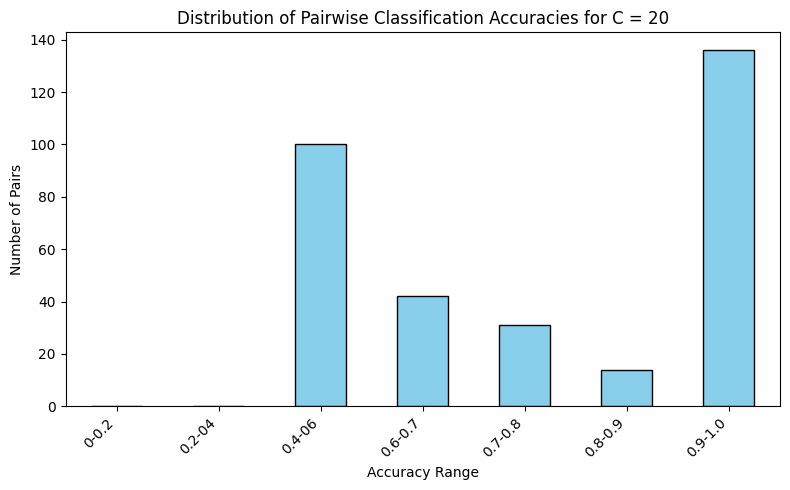

In [26]:

# Seeing the distribution of pairs as per varied range of Accuracy bins for C =20

# Define accuracy bins
accuracy_bins = [0.0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0]
accuracy_labels = ['0-0.2','0.2-04','0.4-06', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']

# Categorize accuracies into bins
accuracy_ranges = pd.cut(results_pairwise_df['Accuracy'], bins=accuracy_bins, labels=accuracy_labels, right=False)

# Get the count of pairs in each range
accuracy_counts = accuracy_ranges.value_counts().sort_index()

# Print the results
print("Pair count for various accuracy ranges:")
print(accuracy_counts)

# Plot the distribution
plt.figure(figsize=(8, 5))
accuracy_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of Pairwise Classification Accuracies for C = 20")
plt.xlabel("Accuracy Range")
plt.ylabel("Number of Pairs")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [27]:
# Convert the top 30 feature dictionary to a list of lists for DataFrame creation

feature_indices_list = []
for pair, indices in feature_indices_pairwise.items():
    feature_indices_list.append([pair[0], pair[1], indices])

# Converting to dataframe
feature_indices_pairwise_df = pd.DataFrame(feature_indices_list, columns=["Class 1", "Class 2", "Top-30 Fisher dimensions"])
feature_indices_pairwise_df.head(5)

,Class 1,Class 2,Top-30 Fisher dimensions
0,A,B,"[0, 1, 9, 8, 21, 11, 10, 32, 28, 29, 41, 30, 3..."
1,A,C,"[0, 3, 4, 7, 16, 15, 30, 31, 29, 28, 36, 22, 2..."
2,A,D,"[0, 3, 4, 7, 8, 17, 18, 23, 22, 35, 36, 39, 28..."
3,A,E,"[0, 1, 2, 3, 4, 13, 12, 21, 20, 49, 48, 28, 27..."
4,A,F,"[0, 14, 13, 17, 21, 20, 16, 15, 1, 2, 26, 27, ..."


In [28]:
# Check for whether any class pair has same set of top 30 features

# Create a Series of feature sets as strings for easier comparison
feature_sets = feature_indices_pairwise_df.iloc[:, 2:].apply(
    lambda row: ','.join(map(str, row.values)), axis=1
)

# Find duplicate feature sets
duplicate_sets = feature_sets[feature_sets.duplicated(keep=False)]

if not duplicate_sets.empty:
    print("Pairs with duplicate feature sets:")
    # Get the indices of the duplicate sets
    duplicate_indices = duplicate_sets.index

    # Print the corresponding class pairs and their feature sets
    for idx in duplicate_indices:
        class1 = feature_indices_pairwise_df.loc[idx, 'Class 1']
        class2 = feature_indices_pairwise_df.loc[idx, 'Class 2']
        features = duplicate_sets.loc[idx]
        print(f"  Pair ({class1}, {class2}) has feature set: [{features}]")
else:
    print("No pairs have the same set of 30 features.")

No pairs have the same set of 30 features.


In [30]:
# Save the results_pairwise_df to a csv for C = 20
results_pairwise_df.to_csv("pairwise_results_C20.csv", index=False)
print("results_pairwise_df for C=20 saved as csv.")

# Save the feature_indices_pairwise_df to a csv for C = 20
feature_indices_pairwise_df.to_csv("pairwise_feature_indices_C20.csv", index=False)
print("feature_indices_pairwise_df for C=20 saved as csv.")

results_pairwise_df for C=20 saved as csv.
feature_indices_pairwise_df for C=20 saved as csv.


###
### **Executing the Linear SVM with top 30 features for C = 10**

In [32]:

# Run pairwise SVM with linear kernel and C=10
results_pairwise_df_C10, feature_indices_pairwise_C10 = run_pairwise_svm(X_test_q4, y_test_q4, class_labels, C=10)


# Print results for accuracy and top 30 features
for c1, c2, acc in results_pairwise_df_C10:
  print(f"Pair ({c1},{c2}) -> Accuracy: {acc:.3f}")
  print(f"Pair ({c1},{c2}) -> Top-30 Fisher dimensions: {feature_indices_pairwise_C10[(c1, c2)]}")

Pair (A,B) -> Accuracy: 0.498
Pair (A,B) -> Top-30 Fisher dimensions: [0, 1, 9, 8, 21, 11, 10, 32, 28, 29, 41, 30, 31, 27, 26, 63, 62, 61, 60, 59, 71, 70, 58, 57, 83, 89, 88, 87, 86, 73]
Pair (A,C) -> Accuracy: 0.596
Pair (A,C) -> Top-30 Fisher dimensions: [0, 3, 4, 7, 16, 15, 30, 31, 29, 28, 36, 22, 21, 41, 42, 55, 49, 50, 68, 69, 40, 39, 58, 59, 64, 65, 38, 37, 96, 103]
Pair (A,D) -> Accuracy: 0.997
Pair (A,D) -> Top-30 Fisher dimensions: [0, 3, 4, 7, 8, 17, 18, 23, 22, 35, 36, 39, 28, 29, 49, 48, 46, 47, 69, 70, 52, 53, 65, 66, 82, 19, 20, 37, 38, 100]
Pair (A,E) -> Accuracy: 0.594
Pair (A,E) -> Top-30 Fisher dimensions: [0, 1, 2, 3, 4, 13, 12, 21, 20, 49, 48, 28, 27, 58, 59, 14, 15, 51, 50, 63, 62, 69, 68, 73, 72, 90, 61, 60, 87, 86]
Pair (A,F) -> Accuracy: 0.690
Pair (A,F) -> Top-30 Fisher dimensions: [0, 14, 13, 17, 21, 20, 16, 15, 1, 2, 26, 27, 18, 19, 24, 25, 10, 9, 54, 53, 61, 74, 75, 72, 73, 90, 67, 66, 94, 93]
Pair (A,G) -> Accuracy: 0.998
Pair (A,G) -> Top-30 Fisher dimensi

In [33]:
# Converting the results_pairwise accuracy to a dataframe
results_pairwise_df_C10 = pd.DataFrame(results_pairwise_df_C10, columns=["Class 1", "Class 2", "Accuracy"])
results_pairwise_df_C10.head(100)


# Convert the top 30 feature dictionary to a list of lists for DataFrame creation
feature_indices_list_C10 = []
for pair, indices in feature_indices_pairwise_C10.items():
    feature_indices_list_C10.append([pair[0], pair[1], indices])

# Converting to dataframe
feature_indices_pairwise_df_C10 = pd.DataFrame(feature_indices_list_C10, columns=["Class 1", "Class 2", "Top-30 Fisher dimensions"])
feature_indices_pairwise_df_C10.head(5)

,Class 1,Class 2,Top-30 Fisher dimensions
0,A,B,"[0, 1, 9, 8, 21, 11, 10, 32, 28, 29, 41, 30, 3..."
1,A,C,"[0, 3, 4, 7, 16, 15, 30, 31, 29, 28, 36, 22, 2..."
2,A,D,"[0, 3, 4, 7, 8, 17, 18, 23, 22, 35, 36, 39, 28..."
3,A,E,"[0, 1, 2, 3, 4, 13, 12, 21, 20, 49, 48, 28, 27..."
4,A,F,"[0, 14, 13, 17, 21, 20, 16, 15, 1, 2, 26, 27, ..."


Pair count for various accuracy ranges:
Accuracy
0-0.2        0
0.2-04       0
0.4-06     202
0.6-0.7     31
0.7-0.8     11
0.8-0.9      8
0.9-1.0     72
Name: count, dtype: int64


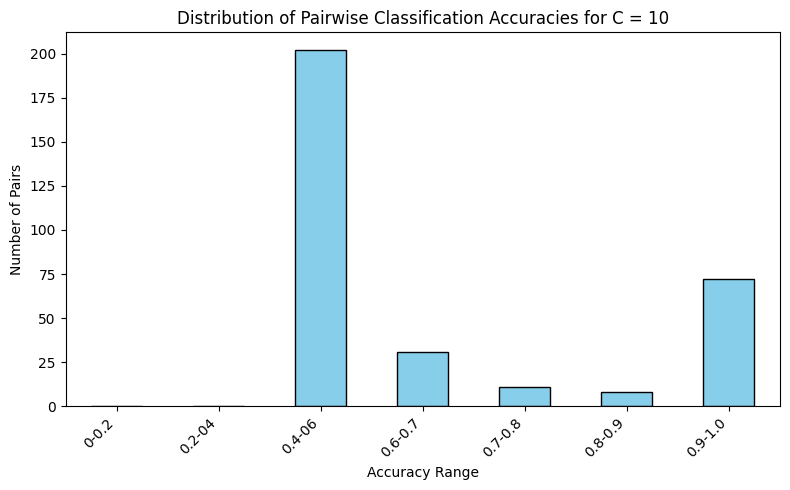

In [49]:

# Seeing the distribution of pairs as per varied range of Accuracy bins for C =20

# Define accuracy bins
accuracy_bins = [0.0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0]
accuracy_labels = ['0-0.2','0.2-04','0.4-06', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']

# Categorize accuracies into bins
accuracy_ranges_C10 = pd.cut(results_pairwise_df_C10['Accuracy'], bins=accuracy_bins, labels=accuracy_labels, right=False)

# Get the count of pairs in each range
accuracy_counts_C10 = accuracy_ranges_C10.value_counts().sort_index()

# Print the results
print("Pair count for various accuracy ranges:")
print(accuracy_counts_C10)

# Plot the distribution
plt.figure(figsize=(8, 5))
accuracy_counts_C10.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of Pairwise Classification Accuracies for C = 10")
plt.xlabel("Accuracy Range")
plt.ylabel("Number of Pairs")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:
# Check for whether any class pair has same set of top 30 features

# Create a Series of feature sets as strings for easier comparison
feature_sets_C10 = feature_indices_pairwise_df_C10.iloc[:, 2:].apply(
    lambda row: ','.join(map(str, row.values)), axis=1
)

# Find duplicate feature sets
duplicate_sets_C10 = feature_sets_C10[feature_sets_C10.duplicated(keep=False)]

if not duplicate_sets_C10.empty:
    print("Pairs with duplicate feature sets:")
    # Get the indices of the duplicate sets
    duplicate_indices_C10 = duplicate_sets_C10.index

    # Print the corresponding class pairs and their feature sets
    for idx in duplicate_indices_C10:
        class1 = feature_indices_pairwise_df_C10.loc[idx, 'Class 1']
        class2 = feature_indices_pairwise_df_C10.loc[idx, 'Class 2']
        features_C10 = duplicate_sets_C10.loc[idx]
        print(f"  Pair ({class1}, {class2}) has feature set: [{features_C10}]")
else:
    print("No pairs have the same set of 30 features for C = 10.")

No pairs have the same set of 30 features for C = 10.


In [36]:
# Save the results_pairwise_df to a csv for C = 10
results_pairwise_df_C10.to_csv("pairwise_results_C10.csv", index=False)
print("results_pairwise_df for C=10 saved as csv.")

# Save the feature_indices_pairwise_df to a csv for C = 10
feature_indices_pairwise_df_C10.to_csv("pairwise_feature_indices_C10.csv", index=False)
print("feature_indices_pairwise_df for C=10 saved as csv.")

results_pairwise_df for C=10 saved as csv.
feature_indices_pairwise_df for C=10 saved as csv.


###
### **Executing the Linear SVM with top 30 features for C = 5**

In [37]:


# Run pairwise SVM with linear kernel and C=5 (default)
results_pairwise_df_c5, feature_indices_pairwise_c5 = run_pairwise_svm(X_test_q4, y_test_q4, class_labels, C=5)


# Print results
for c1, c2, acc in results_pairwise_df_c5:
  print(f"Pair ({c1},{c2}) -> Accuracy: {acc:.3f}")
  print(f"Pair ({c1},{c2}) -> Top-30 Fisher dimensions: {feature_indices_pairwise_c5[(c1, c2)]}")

Pair (A,B) -> Accuracy: 0.498
Pair (A,B) -> Top-30 Fisher dimensions: [0, 1, 9, 8, 21, 11, 10, 32, 28, 29, 41, 30, 31, 27, 26, 63, 62, 61, 60, 59, 71, 70, 58, 57, 83, 89, 88, 87, 86, 73]
Pair (A,C) -> Accuracy: 0.597
Pair (A,C) -> Top-30 Fisher dimensions: [0, 3, 4, 7, 16, 15, 30, 31, 29, 28, 36, 22, 21, 41, 42, 55, 49, 50, 68, 69, 40, 39, 58, 59, 64, 65, 38, 37, 96, 103]
Pair (A,D) -> Accuracy: 0.510
Pair (A,D) -> Top-30 Fisher dimensions: [0, 3, 4, 7, 8, 17, 18, 23, 22, 35, 36, 39, 28, 29, 49, 48, 46, 47, 69, 70, 52, 53, 65, 66, 82, 19, 20, 37, 38, 100]
Pair (A,E) -> Accuracy: 0.581
Pair (A,E) -> Top-30 Fisher dimensions: [0, 1, 2, 3, 4, 13, 12, 21, 20, 49, 48, 28, 27, 58, 59, 14, 15, 51, 50, 63, 62, 69, 68, 73, 72, 90, 61, 60, 87, 86]
Pair (A,F) -> Accuracy: 0.496
Pair (A,F) -> Top-30 Fisher dimensions: [0, 14, 13, 17, 21, 20, 16, 15, 1, 2, 26, 27, 18, 19, 24, 25, 10, 9, 54, 53, 61, 74, 75, 72, 73, 90, 67, 66, 94, 93]
Pair (A,G) -> Accuracy: 0.788
Pair (A,G) -> Top-30 Fisher dimensi

In [38]:
# Convert to dataframe
results_pairwise_df_c5 = pd.DataFrame(results_pairwise_df_c5, columns=["Class 1", "Class 2", "Accuracy"])
results_pairwise_df_c5.head(100)

# Convert the top 30 feature dictionary to a list of lists for DataFrame creation
feature_indices_list_C5 = []
for pair, indices in feature_indices_pairwise_c5.items():
    feature_indices_list_C5.append([pair[0], pair[1], indices])

# Converting to dataframe
feature_indices_pairwise_df_C5 = pd.DataFrame(feature_indices_list_C5, columns=["Class 1", "Class 2", "Top-30 Fisher dimensions"])
print(feature_indices_pairwise_df_C5.head(5))


  Class 1 Class 2                           Top-30 Fisher dimensions
0       A       B  [0, 1, 9, 8, 21, 11, 10, 32, 28, 29, 41, 30, 3...
1       A       C  [0, 3, 4, 7, 16, 15, 30, 31, 29, 28, 36, 22, 2...
2       A       D  [0, 3, 4, 7, 8, 17, 18, 23, 22, 35, 36, 39, 28...
3       A       E  [0, 1, 2, 3, 4, 13, 12, 21, 20, 49, 48, 28, 27...
4       A       F  [0, 14, 13, 17, 21, 20, 16, 15, 1, 2, 26, 27, ...


Pair count for various accuracy ranges:
Accuracy
0-0.2        0
0.2-04       0
0.4-06     264
0.6-0.7     20
0.7-0.8      8
0.8-0.9      1
0.9-1.0     31
Name: count, dtype: int64


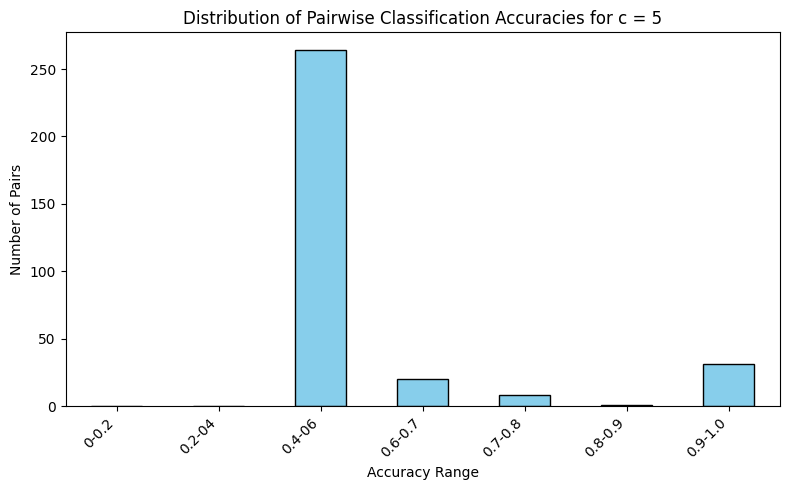

In [40]:
# Define accuracy bins
accuracy_bins = [0.0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0]
accuracy_labels = ['0-0.2','0.2-04','0.4-06', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']

# Categorize accuracies into bins
accuracy_ranges_C5 = pd.cut(results_pairwise_df_c5['Accuracy'], bins=accuracy_bins, labels=accuracy_labels, right=False)

# Get the count of pairs in each range
accuracy_counts_C5 = accuracy_ranges_C5.value_counts().sort_index()

# Print the results
print("Pair count for various accuracy ranges:")
print(accuracy_counts_C5)

# Plot the distribution
plt.figure(figsize=(8, 5))
accuracy_counts_C5.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of Pairwise Classification Accuracies for c = 5")
plt.xlabel("Accuracy Range")
plt.ylabel("Number of Pairs")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [41]:


# Check for whether any class pair has same set of top 30 features

# Create a Series of feature sets as strings for easier comparison
feature_sets_C5 = feature_indices_pairwise_df_C5.iloc[:, 2:].apply(
    lambda row: ','.join(map(str, row.values)), axis=1
)

# Find duplicate feature sets
duplicate_sets_C5 = feature_sets_C5[feature_sets_C5.duplicated(keep=False)]

if not duplicate_sets_C5.empty:
    print("Pairs with duplicate feature sets:")
    # Get the indices of the duplicate sets
    duplicate_indices_C5 = duplicate_sets_C5.index

    # Print the corresponding class pairs and their feature sets
    for idx in duplicate_indices_C5:
        class1 = feature_indices_pairwise_df_C5.loc[idx, 'Class 1']
        class2 = feature_indices_pairwise_df_C5.loc[idx, 'Class 2']
        features_C5 = duplicate_sets_C5.loc[idx]
        print(f"  Pair ({class1}, {class2}) has feature set: [{features_C5}]")
else:
    print("\n\nNo pairs have the same set of 30 features.")



No pairs have the same set of 30 features.


In [42]:
# Save the results_pairwise_df to a csv for C = 5
results_pairwise_df_c5.to_csv("pairwise_results_C5.csv", index=False)
print("results_pairwise_df for C=5 saved as csv")

# Save the feature_indices_pairwise_df to a csv for C = 5
feature_indices_pairwise_df_C5.to_csv("pairwise_feature_indices_C5.csv", index=False)
print("feature_indices_pairwise_df for C=5 saved as csv")

results_pairwise_df for C=5 saved as csv
feature_indices_pairwise_df for C=5 saved as csv


###
### **Executing the Linear SVM with top 30 features for C = 1**

In [ ]:
# Run pairwise SVM with linear kernel and C=1 (default)
results_pairwise_df_c1, feature_indices_pairwise_c1 = run_pairwise_svm(X_test_q4, y_test_q4, class_labels, C=1)


# Print results for C = 1
for c1, c2, acc in results_pairwise_df_c1:
  print(f"Pair ({c1},{c2}) -> Accuracy: {acc:.3f}")
  print(f"Pair ({c1},{c2}) -> Top-30 Fisher dimensions: {feature_indices_pairwise_c1[(c1, c2)]}")

Pair (A,B) -> Accuracy: 0.499
Pair (A,B) -> Top-30 Fisher dimensions: [0, 1, 9, 8, 21, 11, 10, 32, 28, 29, 41, 30, 31, 27, 26, 63, 62, 61, 60, 59, 71, 70, 58, 57, 83, 89, 88, 87, 86, 73]
Pair (A,C) -> Accuracy: 0.598
Pair (A,C) -> Top-30 Fisher dimensions: [0, 3, 4, 7, 16, 15, 30, 31, 29, 28, 36, 22, 21, 41, 42, 55, 49, 50, 68, 69, 40, 39, 58, 59, 64, 65, 38, 37, 96, 103]
Pair (A,D) -> Accuracy: 0.498
Pair (A,D) -> Top-30 Fisher dimensions: [0, 3, 4, 7, 8, 17, 18, 23, 22, 35, 36, 39, 28, 29, 49, 48, 46, 47, 69, 70, 52, 53, 65, 66, 82, 19, 20, 37, 38, 100]
Pair (A,E) -> Accuracy: 0.582
Pair (A,E) -> Top-30 Fisher dimensions: [0, 1, 2, 3, 4, 13, 12, 21, 20, 49, 48, 28, 27, 58, 59, 14, 15, 51, 50, 63, 62, 69, 68, 73, 72, 90, 61, 60, 87, 86]
Pair (A,F) -> Accuracy: 0.498
Pair (A,F) -> Top-30 Fisher dimensions: [0, 14, 13, 17, 21, 20, 16, 15, 1, 2, 26, 27, 18, 19, 24, 25, 10, 9, 54, 53, 61, 74, 75, 72, 73, 90, 67, 66, 94, 93]
Pair (A,G) -> Accuracy: 0.655
Pair (A,G) -> Top-30 Fisher dimensi

In [16]:
# Convert to dataframe
results_pairwise_df_c1 = pd.DataFrame(results_pairwise_df_c1, columns=["Class 1", "Class 2", "Accuracy"])
results_pairwise_df_c1.head(100)

,Class 1,Class 2,Accuracy
0,A,B,0.498841
1,A,C,0.597678
2,A,D,0.498261
3,A,E,0.581980
4,A,F,0.497681
...,...,...,...
95,E,G,0.614493
96,E,H,0.790725
97,E,I,0.497098
98,E,J,0.498261


Pair count for various accuracy ranges:
Accuracy
0-0.2        0
0.2-04       0
0.4-06     302
0.6-0.7     16
0.7-0.8      2
0.8-0.9      0
0.9-1.0      4
Name: count, dtype: int64


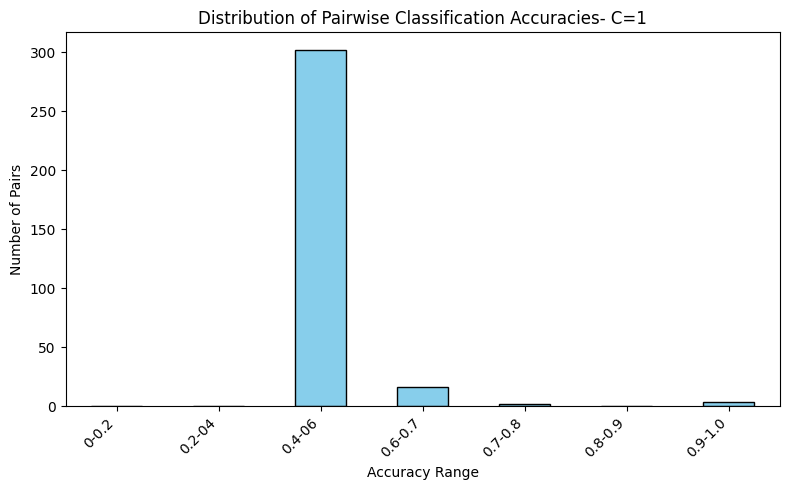

In [18]:
# Define accuracy bins
accuracy_bins = [0.0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0]
accuracy_labels = ['0-0.2','0.2-04','0.4-06', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']

# Categorize accuracies into bins
accuracy_ranges_c1 = pd.cut(results_pairwise_df_c1['Accuracy'], bins=accuracy_bins, labels=accuracy_labels, right=False)

# Get the count of pairs in each range
accuracy_counts_c1 = accuracy_ranges_c1.value_counts().sort_index()

# Print the results
print("Pair count for various accuracy ranges:")
print(accuracy_counts_c1)

# Plot the distribution
plt.figure(figsize=(8, 5))
accuracy_counts_c1.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of Pairwise Classification Accuracies- C=1")
plt.xlabel("Accuracy Range")
plt.ylabel("Number of Pairs")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [44]:
# Convert the top 30 feature dictionary to a list of lists for DataFrame creation

feature_indices_list_C1 = []
for pair, indices in feature_indices_pairwise_c1.items():
    feature_indices_list_C1.append([pair[0], pair[1], indices])

# Converting to dataframe
feature_indices_pairwise_df_C1 = pd.DataFrame(feature_indices_list_C1, columns=["Class 1", "Class 2", "Top-30 Fisher dimensions"])
print(feature_indices_pairwise_df_C1.head(5))


# Check for whether any class pair has same set of top 30 features

# Create a Series of feature sets as strings for easier comparison
feature_sets_C1 = feature_indices_pairwise_df_C1.iloc[:, 2:].apply(
    lambda row: ','.join(map(str, row.values)), axis=1
)

# Find duplicate feature sets
duplicate_sets_C1 = feature_sets_C1[feature_sets_C1.duplicated(keep=False)]

if not duplicate_sets_C1.empty:
    print("Pairs with duplicate feature sets:")
    # Get the indices of the duplicate sets
    duplicate_indices_C1 = duplicate_sets_C1.index

    # Print the corresponding class pairs and their feature sets
    for idx in duplicate_indices_C1:
        class1 = feature_indices_pairwise_df_C1.loc[idx, 'Class 1']
        class2 = feature_indices_pairwise_df_C1.loc[idx, 'Class 2']
        features = duplicate_sets.loc[idx]
        print(f"  Pair ({class1}, {class2}) has feature set: [{features_C1}]")
else:
    print("\n\nNo pairs have the same set of 30 features.")

  Class 1 Class 2                           Top-30 Fisher dimensions
0       A       B  [0, 1, 9, 8, 21, 11, 10, 32, 28, 29, 41, 30, 3...
1       A       C  [0, 3, 4, 7, 16, 15, 30, 31, 29, 28, 36, 22, 2...
2       A       D  [0, 3, 4, 7, 8, 17, 18, 23, 22, 35, 36, 39, 28...
3       A       E  [0, 1, 2, 3, 4, 13, 12, 21, 20, 49, 48, 28, 27...
4       A       F  [0, 14, 13, 17, 21, 20, 16, 15, 1, 2, 26, 27, ...


No pairs have the same set of 30 features.


In [46]:
# Save the results_pairwise_df to a csv for C =1
results_pairwise_df_c1.to_csv("pairwise_results_C1.csv", index=False)
print("results_pairwise_df for C = 1 saved  as csv")

# Save the feature_indices_pairwise_df to a csv for C = 1
feature_indices_pairwise_df_C1.to_csv("pairwise_feature_indices_C1.csv", index=False)
print("feature_indices_pairwise_df for C = 1 saved as csv")

results_pairwise_df for C = 1 saved  as csv
feature_indices_pairwise_df for C = 1 saved as csv


###
### **Observation:**
- We see that as we increase the value of C, number of pairs with higher accuracy of classification starts increasing.
- As C=1, we have very less pairs that go beyond the accuracty of 40%
- As C increases to 5, We observate few pairs starting to have an accuracy of more than 40%, some reaches to ~80-100% too.
- As C increases to 10, we observe many pairs with an accuracy of 80-100%
- For C = 20, we have very high count of pairs with accuracy between 80-100%
###
**As I continue to increase C, pair count with lesser accuracy starts going down and pair count with better accuracy starts going up.**

**I still have some pairs that has an accuracy of between 40-60%. I have created a histogram of pair count distribution across accuracy range for various C to observe this change in accuracy for class pairs**

**For C = 30, pair count with accuracy < 60% is very less compared to other C values. And the count with accuract between 90 to 100 is very high**

**At C = 50, majority of pair have a classification accuracy in the range of 90 to 100%. Going with this value of C (not moving further as we have observed the effect for a quite a few value of C)**

**I will now analyse those pairs that still falls under low accuracy range, maybe they are pairs that has higher similarity and difficult to classify**



###
### **Easy vs Difficult Classification Pair as per C = 50 results**

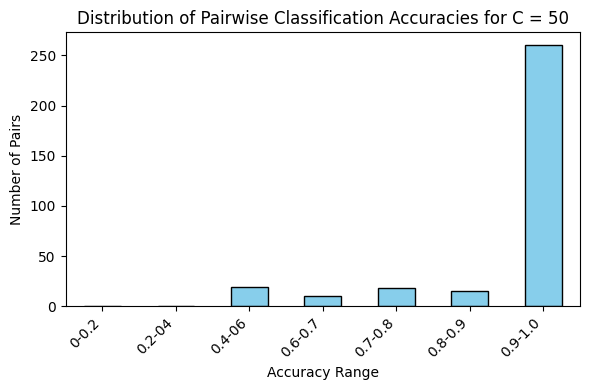

In [50]:
# Plot the distribution
plt.figure(figsize=(6, 4))
accuracy_counts_C50.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of Pairwise Classification Accuracies for C = 50")
plt.xlabel("Accuracy Range")
plt.ylabel("Number of Pairs")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [57]:
# Filter the DataFrame for pairs with accuracy less than 0.6
low_accuracy_pairs = results_pairwise_df_C50[results_pairwise_df_C50['Accuracy'] < 0.6]

# Display the unique class pairs
print("Unique class pairs with accuracy less than 60%:")
display(low_accuracy_pairs[['Class 1', 'Class 2']])

# Print the count of these pairs
print(f"\nTotal count of pairs with accuracy less than 60%: {len(low_accuracy_pairs)}")

Unique class pairs with accuracy less than 60%:


,Class 1,Class 2
44,B,V
57,C,L
66,C,U
98,E,J
100,E,L
117,F,I
124,F,P
141,G,N
144,G,Q
148,G,U



Total count of pairs with accuracy less than 60%: 19


###
### Interpretation for Low Accuracy Pairs (Difficult Pairs):
These are the pairs that have the lowest accuracy among all pairs. These seems to be diffcult to classify pairs.
1. **Poor Separation in Feature Space**: Top 30 features selected for these pairs are not very discriminative and not easily separable in the feture space.
2. **Influence of Regularization (C)**: If we increase the value of C, maybe we will be able to get more accurate pairs with much better accuracy. Because of time comstraints, I have not tried too many values of C.
3. **Visually not distinguishable**: These pairs might be very similar looking classes that are visually not easily separable and fetaure space may not be easily separable in terms of between class scatter.

In [61]:
# Filter the DataFrame for pairs with accuracy between 60 and 80%
moderate_accuracy_pairs = results_pairwise_df_C50[(results_pairwise_df_C50['Accuracy'] >= 0.6) & (results_pairwise_df_C50['Accuracy'] < 0.8)]

# Display the unique class pairs
print("Unique class pairs with accuracy between 60 and 80%:")
display(moderate_accuracy_pairs[['Class 1', 'Class 2']])

# Print the count of these pairs
print(f"\nTotal count of pairs with accuracy between 60 and 80%: {len(moderate_accuracy_pairs)}")

Unique class pairs with accuracy between 60 and 80%:


,Class 1,Class 2
25,B,C
32,B,J
34,B,L
49,C,D
54,C,I
60,C,O
61,C,P
62,C,Q
64,C,S
79,D,L



Total count of pairs with accuracy between 60 and 80%: 28


###
#### Interpretation for Moderate Accuracy Pairs (Moderate Pairs):
- These are the pairs that have moderate accuracy i.e. between 60 and 80%
- The classifications are neither very good (easily separabel) nor very bad (not separable at all).
- **1. Poor Separation in Feature Space**: Top 30 features selected for these pairs are not very discriminative and not easily separable in the feture space.
- **2. Limitations of Linear Kernel:** These pairs might not be easily separable by Linear SVM but may work well with other non-linear SVM.
- **3. Influence of Regularization (C)**: If we increase the value of C, maybe we will be able to get more accurate pairs with much better accuracy.
Because of time comstraints, I have not tried too many values of C.
- **4. Borderline Cases**: These might be pairs where some samples are easily distinguishable, while others are closer to the decision boundary or fall into the overlapping region.

In [62]:
# Filter the DataFrame for pairs with accuracy high accuracy >= 80%
high_accuracy_pairs = results_pairwise_df_C50[results_pairwise_df_C50['Accuracy'] >= 0.8]

# Display the unique class pairs
print("Unique class pairs with accuracy more than 80%:")
display(high_accuracy_pairs[['Class 1', 'Class 2']])

# Print the count of these pairs
print(f"\nTotal count of pairs with accuracy more than 80%: {len(high_accuracy_pairs)}")

Unique class pairs with accuracy more than 80%:


,Class 1,Class 2
0,A,B
1,A,C
2,A,D
3,A,E
4,A,F
...,...,...
320,W,Y
321,W,Z
322,X,Y
323,X,Z



Total count of pairs with accuracy more than 80%: 278


###
#### Interpretation for High Accuracy Pairs (Easy Pairs):
- These are the pairs that seems to have the highest accuracy, especially in the range of 90-100%
- **1. Well-Separated Classes**: Such high accuracy indicate that these pairs are easily separable by linear boundary with the top 30 selected features.
- **2. Discriminative Features**: Top 30 fetaures selected by LDA may have chosen such features that maximises the between class scatter and minimises the within class variance very well.
- **3. Visual Distinctiveness**: Visually, these pairs of classes could be very distinct to be able to separate them easily.

###
#### Top 30 Fisher Projection per class pair:
- For c = 50 results (and others too), we have No pair of classes that have generated same set of Top 30 feature projections.
- It indicates that Class separability is highly pair dependent. Different pairs of classes may have completely different feature projection For example A,B and A,C will need to work with completely different set of feature space to be able to classify them accurately.
